# Random Forest bez czarnej skrzynki
### Breast Cancer Wisconsin (Diagnostic) — algorytm od podstaw, z dziennikiem decyzji i wizualizacjami

W tym notebooku **budujemy Random Forest od zera w NumPy** i na każdym kroku zapisujemy, *co* algorytm zrobił i *dlaczego*:

| krok | co logujemy | co wizualizujemy |
|---|---|---|
| bootstrap | które próbki wylosowano, które są OOB | rozkład powtórzeń vs Poisson(1) |
| węzeł drzewa | wylosowane cechy, najlepszy próg każdej, spadek Gini | ranking kandydatów, skan progów |
| liść | dlaczego przestaliśmy dzielić | drzewo z kolorem P(złośliwy) |
| las | błąd OOB po każdym drzewie | krzywa uczenia, niezgoda drzew |
| predykcja | głos każdego drzewa, margines | histogram głosów, wodospad wkładów cech |

Biblioteka **scikit-learn służy wyłącznie do wczytania danych i jako punkt odniesienia** (sprawdzamy, że nasza implementacja daje te same wyniki).

**Plan:** 1) dane → 2) dziennik zdarzeń → 3) Gini i wybór progu → 4) drzewo → 5) niestabilność drzewa → 6) las → 7) dynamika zespołu → 8) ocena → 9) ważność globalna → 10) wyjaśnienie pojedynczej predykcji → 11) dlaczego (i kiedy) Random Forest → ćwiczenia.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from math import exp, factorial
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from sklearn.datasets import load_breast_cancer

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)
%matplotlib inline

<details><summary><b>Kod wykresów</b> (nie jest częścią algorytmu, komórka poniżej jest zwinięta)</summary>

Stałe kolory: <span style="color:#2a78d6">■ niebieski = łagodny</span>, <span style="color:#eb6834">■ pomarańczowy = złośliwy</span>, ■ szary = kontekst.
</details>

In [2]:
BENIGN = "#2a78d6"
MALIGNANT = "#eb6834"
NEUTRAL = "#a3a29c"
INK = "#0b0b0b"
INK2 = "#52514e"
GRID = "#e6e5e1"
SURFACE = "#fcfcfb"
AQUA = "#1baf7a"
VIOLET = "#4a3aa7"

DIVERGING = LinearSegmentedColormap.from_list("bm", [BENIGN, "#f0efec", MALIGNANT])


def setup_style():
    plt.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
        "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
        "axes.labelsize": 10, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 9, "ytick.labelsize": 9,
        "legend.frameon": False, "legend.fontsize": 9, "font.size": 10,
        "lines.linewidth": 2, "figure.dpi": 110, "axes.axisbelow": True,
    })


setup_style()


def _mix(p):
    """Kolor węzła: od niebieskiego (P=0) do pomarańczowego (P=1), rozjaśniony."""
    b, m = np.array(to_rgb(BENIGN)), np.array(to_rgb(MALIGNANT))
    c = (1 - p) * b + p * m
    return tuple(0.55 * c + 0.45 * np.ones(3))


def _short(name, n=22):
    return name if len(name) <= n else name[: n - 1] + "…"


# ==========================================================================
# Drzewo
# ==========================================================================
def plot_tree(tree, feature_names, max_depth=3, highlight_path=None, title=None,
              show_ids=True):
    """Rysuje drzewo do głębokości max_depth. Głębsze poddrzewa → „⋯”.

    highlight_path – lista id węzłów (np. ścieżka jednej pacjentki).
    """
    nodes = tree.nodes_
    hp = set(highlight_path or [])
    pos, order = {}, []

    def layout(i):
        nd = nodes[i]
        if nd.is_leaf or nd.depth >= max_depth:
            pos[i] = (len(order), -nd.depth)
            order.append(i)
            return pos[i][0]
        xl = layout(nd.left)
        xr = layout(nd.right)
        pos[i] = ((xl + xr) / 2, -nd.depth)
        return pos[i][0]

    layout(0)
    n_leaves = len(order)
    depth_shown = max(-p[1] for p in pos.values())
    fig, ax = plt.subplots(figsize=(max(8, 1.9 * n_leaves), 1.55 * (depth_shown + 1) + 0.8))
    ax.set_axis_off()

    for i, (x, yv) in pos.items():
        nd = nodes[i]
        if not nd.is_leaf and nd.depth < max_depth:
            for c in (nd.left, nd.right):
                cx, cy = pos[c]
                on = i in hp and c in hp
                ax.plot([x, cx], [yv - 0.18, cy + 0.2], color=INK if on else NEUTRAL,
                        lw=3 if on else 1.2, zorder=1)
                lab = "tak" if c == nd.left else "nie"
                ax.text((x + cx) / 2, (yv + cy) / 2, lab, fontsize=7.5, color=INK2,
                        ha="center", va="center",
                        bbox=dict(boxstyle="round,pad=0.15", fc=SURFACE, ec="none"))

    for i, (x, yv) in pos.items():
        nd = nodes[i]
        p = nd.proba[1]
        truncated = (not nd.is_leaf) and nd.depth >= max_depth
        if nd.is_leaf:
            txt = f"LIŚĆ  P(zł)={p:.2f}\nn={nd.n}  [{nd.counts[0]} | {nd.counts[1]}]"
        elif truncated:
            txt = f"⋯ poddrzewo\nn={nd.n}  [{nd.counts[0]} | {nd.counts[1]}]"
        else:
            txt = (f"{_short(feature_names[nd.feature])}\n≤ {nd.threshold:.4g}?\n"
                   f"Gini {nd.impurity:.3f}  n={nd.n}\n[{nd.counts[0]} | {nd.counts[1]}]")
        if show_ids:
            txt = f"#{i}  " + txt
        on = i in hp
        ax.text(x, yv, txt, ha="center", va="center", fontsize=8, color=INK, zorder=3,
                bbox=dict(boxstyle="round,pad=0.4", fc=_mix(p),
                          ec=INK if on else "white", lw=2.2 if on else 1))

    ax.set_xlim(-0.8, n_leaves - 0.2)
    ax.set_ylim(-depth_shown - 0.6, 0.6)
    ax.set_title(title or f"Drzewo #{tree.tree_id_} (pokazano do głębokości {max_depth}; "
                 f"[łagodne | złośliwe])", loc="left")
    fig.tight_layout()
    return fig


# ==========================================================================
# Decyzja w węźle: kandydaci i skan progów
# ==========================================================================
def plot_split_candidates(event, ax=None):
    """Spadek Gini dla każdej wylosowanej cechy-kandydatki w węźle."""
    cands = [c for c in event["candidates"] if c["gain"] is not None][::-1]
    fig = None
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 0.45 * len(cands) + 1.2))
    names = [c["name"] for c in cands]
    gains = [c["gain"] for c in cands]
    colors = [MALIGNANT if c["name"] == event["name"] else NEUTRAL for c in cands]
    ax.barh(names, gains, color=colors, height=0.6)
    for k, c in enumerate(cands):
        ax.text(c["gain"], k, f"  {c['gain']:.4f}  (próg {c['threshold']:.4g})",
                va="center", fontsize=8.5, color=INK2)
    ax.set_xlabel("spadek nieczystości Gini po podziale (im więcej, tym lepiej)")
    ax.set_xlim(0, max(gains) * 1.6)
    ax.grid(axis="y", visible=False)
    ax.set_title(f"Węzeł #{event['node_id']}: która wylosowana cecha dzieli najlepiej?")
    if fig:
        fig.tight_layout()
    return fig or ax.figure


def plot_gini_scan(Xn, yn, features, feature_names, chosen=None, parent_gini=None,
                   ncols=3):
    """Ważony Gini dzieci dla KAŻDEGO możliwego progu – po jednym panelu na cechę."""
    k = len(features)
    ncols = min(ncols, k)
    nrows = int(np.ceil(k / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.9 * nrows),
                             squeeze=False, sharey=True)
    for a, f in zip(axes.flat, features):
        thr, w = scan_feature(Xn[:, f], yn, 2)
        is_best = f == chosen
        col = MALIGNANT if is_best else INK2
        if len(thr):
            a.plot(thr, w, color=col, lw=1.8)
            i = int(np.argmin(w))
            a.scatter([thr[i]], [w[i]], s=60, color=col, zorder=3, edgecolor=SURFACE, lw=2)
            low = parent_gini is None or w[i] < 0.8 * parent_gini
            a.annotate(f"min {w[i]:.3f}\nprzy {thr[i]:.4g}", (thr[i], w[i]),
                       textcoords="offset points", xytext=(8, 10) if low else (8, -30),
                       fontsize=8, color=INK2)
        if parent_gini is not None:
            a.axhline(parent_gini, color=NEUTRAL, ls="--", lw=1)
        a.set_title(("★ " if is_best else "") + _short(feature_names[f], 30), fontsize=10)
        a.set_xlabel("próg")
    for a in axes[:, 0]:
        a.set_ylabel("ważony Gini dzieci")
    for a in list(axes.flat)[k:]:
        a.set_visible(False)
    fig.suptitle("Skan wszystkich progów (linia przerywana = Gini rodzica; "
                 "★ = zwycięska cecha)", x=0.01, ha="left", fontsize=11, color=INK)
    fig.tight_layout()
    return fig


# ==========================================================================
# Trening lasu
# ==========================================================================
def plot_bootstrap(inbag_counts, tree_id=0):
    """Ile razy każda próbka trafiła do bootstrapu drzewa (0 = OOB)."""
    from math import exp, factorial
    c = inbag_counts[tree_id]
    n = len(c)
    hist = np.bincount(c)
    ks = np.arange(len(hist))
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.bar(ks, hist / n, color=[NEUTRAL if k == 0 else BENIGN for k in ks], width=0.7)
    pois = [exp(-1) / factorial(int(k)) for k in ks]
    ax.plot(ks, pois, "o--", color=INK, lw=1.2, ms=6, label="teoria: Poisson(1)")
    ax.text(0, max(hist[0] / n, exp(-1)) + 0.02, f"OOB: {hist[0] / n:.1%}\n(teoria ≈ 36,8%)",
            fontsize=9, color=INK2, va="bottom", ha="center")
    ax.set_ylim(0, max(hist.max() / n, exp(-1)) + 0.1)
    ax.set_xticks(ks)
    ax.set_xlabel("ile razy próbka została wylosowana")
    ax.set_ylabel("odsetek próbek")
    ax.set_title(f"Bootstrap drzewa #{tree_id}: losowanie {n} próbek ze zwracaniem")
    ax.legend()
    fig.tight_layout()
    return fig


def plot_oob_curve(forest, test_acc=None, single_tree_err=None):
    """Błąd OOB (i ew. testowy) w miarę dodawania drzew."""
    curve = np.array(forest.oob_curve_)
    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.plot(curve[:, 0], curve[:, 1], color=BENIGN, label="błąd OOB lasu")
    if test_acc is not None:
        ax.plot(np.arange(1, len(test_acc) + 1), 1 - np.asarray(test_acc), color=MALIGNANT,
                label="błąd na zbiorze testowym")
    if single_tree_err is not None:
        ax.axhline(single_tree_err, color=NEUTRAL, ls="--", lw=1.4,
                   label=f"średni błąd pojedynczego drzewa ({single_tree_err:.3f})")
    ax.set_xlabel("liczba drzew w lesie")
    ax.set_ylabel("odsetek błędów")
    ax.set_ylim(bottom=0)
    ax.set_title("Jak błąd maleje wraz z liczbą drzew")
    ax.legend(loc="center right")
    fig.tight_layout()
    return fig


def plot_root_features(forest_counts, stability=None):
    """Cechy w korzeniu: drzewa lasu vs pojedyncze drzewa na bootstrapach."""
    ncols = 2 if stability else 1
    fig, axes = plt.subplots(1, ncols, figsize=(6.5 * ncols, 4), squeeze=False)
    a = axes[0, 0]
    names = list(forest_counts)[::-1]
    a.barh(names, [forest_counts[n] for n in names], color=BENIGN, height=0.6)
    a.set_title("Random Forest: cecha w korzeniu")
    a.set_xlabel("liczba drzew")
    a.grid(axis="y", visible=False)
    if stability:
        c = {}
        for r in stability:
            c[r["root"]] = c.get(r["root"], 0) + 1
        names = sorted(c, key=c.get)
        b = axes[0, 1]
        b.barh(names, [c[n] for n in names], color=NEUTRAL, height=0.6)
        b.set_title("Pojedyncze drzewo (wszystkie cechy)\nna różnych bootstrapach")
        b.set_xlabel("liczba uruchomień")
        b.grid(axis="y", visible=False)
    fig.tight_layout()
    return fig


def plot_disagreement(dis):
    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    im = ax.imshow(dis, cmap=LinearSegmentedColormap.from_list("s", ["#f0efec", VIOLET]))
    ax.set_title("Niezgoda par drzew (odsetek różnych predykcji)")
    ax.set_xlabel("drzewo")
    ax.set_ylabel("drzewo")
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout()
    return fig


# ==========================================================================
# Ważność cech
# ==========================================================================
def plot_importances(names, mdi, perm, perm_err=None, top_k=15,
                     perm_label="permutacyjna (OOB)"):
    """Dwa panele z tą samą kolejnością cech: MDI oraz ważność permutacyjna."""
    names = np.asarray(names)
    idx = np.argsort(-mdi)[:top_k][::-1]
    fig, axes = plt.subplots(1, 2, figsize=(12, 0.32 * top_k + 1.6), sharey=True)
    axes[0].barh(names[idx], mdi[idx], color=BENIGN, height=0.62)
    axes[0].set_title("MDI – średni spadek Gini (z logów)")
    axes[0].set_xlabel("udział w łącznym spadku Gini")
    axes[1].barh(names[idx], perm[idx], color=MALIGNANT, height=0.62,
                 xerr=None if perm_err is None else perm_err[idx],
                 error_kw=dict(ecolor=INK2, lw=1, capsize=2))
    axes[1].set_title(f"Ważność {perm_label}")
    axes[1].set_xlabel("spadek dokładności po wymieszaniu cechy")
    axes[1].axvline(0, color=INK2, lw=0.8)
    for a in axes:
        a.grid(axis="y", visible=False)
    fig.tight_layout()
    return fig


def plot_correlation(X, names, features):
    """Korelacje Pearsona wybranych cech – źródło „rozmycia” ważności MDI."""
    C = np.corrcoef(X[:, features].T)
    fig, ax = plt.subplots(figsize=(0.55 * len(features) + 3, 0.55 * len(features) + 2))
    im = ax.imshow(C, cmap=DIVERGING, vmin=-1, vmax=1)
    labs = [_short(names[f], 20) for f in features]
    ax.set_xticks(range(len(features)), labs, rotation=60, ha="right")
    ax.set_yticks(range(len(features)), labs)
    for i in range(len(features)):
        for j in range(len(features)):
            ax.text(j, i, f"{C[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color=INK)
    ax.grid(False)
    ax.set_title("Korelacje najważniejszych cech")
    fig.colorbar(im, ax=ax, shrink=0.7)
    fig.tight_layout()
    return fig


# ==========================================================================
# Wyjaśnienie pojedynczej predykcji
# ==========================================================================
def plot_waterfall(bias, contrib, names, x, top_k=10, title=None):
    """Wodospad Saabasa: od wartości bazowej do P(złośliwy) lasu."""
    names = np.asarray(names)
    order = np.argsort(-np.abs(contrib))
    top, rest = order[:top_k], order[top_k:]
    labels = [f"{_short(names[j], 24)} = {x[j]:.4g}" for j in top]
    vals = list(contrib[top])
    if len(rest):
        labels.append(f"pozostałe cechy ({len(rest)})")
        vals.append(float(contrib[rest].sum()))
    fig, ax = plt.subplots(figsize=(9, 0.42 * (len(vals) + 2) + 1.2))
    cur = bias
    ys = np.arange(len(vals) + 2)[::-1]
    ax.barh(ys[0], bias, color=NEUTRAL, height=0.6)
    ax.text(bias, ys[0], f"  {bias:.3f}", va="center", fontsize=9, color=INK2)
    for k, v in enumerate(vals):
        ax.barh(ys[k + 1], v, left=cur, color=MALIGNANT if v > 0 else BENIGN, height=0.6)
        ax.text(max(cur, cur + v), ys[k + 1], f"  {v:+.3f}", va="center", fontsize=8.5,
                color=INK2)
        cur += v
    ax.barh(ys[-1], cur, color=MALIGNANT if cur >= 0.5 else BENIGN, height=0.6)
    ax.text(cur, ys[-1], f"  {cur:.3f}", va="center", fontsize=9, color=INK,
            fontweight="bold")
    ax.axvline(0.5, color=INK2, ls="--", lw=1)
    ax.set_yticks(ys, ["wartość bazowa"] + labels + ["P(złośliwy) lasu"])
    ax.set_xlim(0, 1.08)
    ax.set_xlabel("P(złośliwy)   (pomarańcz = w stronę złośliwy, niebieski = w stronę łagodny)")
    ax.grid(axis="y", visible=False)
    ax.set_title(title or "Dlaczego taka predykcja? Wkład cech (dekompozycja Saabasa)")
    fig.tight_layout()
    return fig


def plot_tree_votes(per_tree_p, title=None):
    """Rozkład P(złośliwy) zwróconych przez poszczególne drzewa."""
    per_tree_p = np.asarray(per_tree_p)
    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    bins = np.linspace(0, 1, 21)
    ax.hist(per_tree_p[per_tree_p < 0.5], bins=bins, color=BENIGN, rwidth=0.88,
            label=f"głos „łagodny”: {(per_tree_p < 0.5).sum()}")
    ax.hist(per_tree_p[per_tree_p >= 0.5], bins=bins, color=MALIGNANT, rwidth=0.88,
            label=f"głos „złośliwy”: {(per_tree_p >= 0.5).sum()}")
    ax.axvline(per_tree_p.mean(), color=INK, lw=2,
               label=f"średnia = predykcja lasu ({per_tree_p.mean():.3f})")
    ax.axvline(0.5, color=INK2, ls="--", lw=1)
    ax.set_xlabel("P(złośliwy) w liściu danego drzewa")
    ax.set_ylabel("liczba drzew")
    ax.set_title(title or "Jak głosowały drzewa?")
    ax.legend(loc="upper center")
    fig.tight_layout()
    return fig


def plot_margins(margins, title=None):
    margins = np.asarray(margins)
    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    bins = np.linspace(-1, 1, 41)
    ax.hist(margins[margins > 0], bins=bins, color=AQUA, rwidth=0.88,
            label=f"poprawne ({(margins > 0).sum()})")
    ax.hist(margins[margins <= 0], bins=bins, color=MALIGNANT, rwidth=0.88,
            label=f"błędne lub remis ({(margins <= 0).sum()})")
    ax.axvline(0, color=INK2, ls="--", lw=1)
    ax.set_xlabel("margines głosów  (−1 = wszystkie drzewa się mylą, +1 = wszystkie trafiają)")
    ax.set_ylabel("liczba pacjentek")
    ax.set_title(title or "Pewność lasu na zbiorze testowym")
    ax.legend(loc="upper left")
    fig.tight_layout()
    return fig


# ==========================================================================
# Ocena
# ==========================================================================
def plot_confusion(cm, class_names=("łagodny", "złośliwy"), title="Macierz pomyłek"):
    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    ax.imshow(cm, cmap=LinearSegmentedColormap.from_list("b", ["#f0efec", BENIGN]))
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=16,
                    color="white" if cm[i, j] > cm.max() / 2 else INK, fontweight="bold")
    ax.set_xticks(range(len(class_names)), class_names)
    ax.set_yticks(range(len(class_names)), class_names)
    ax.set_xlabel("przewidziana klasa")
    ax.set_ylabel("prawdziwa klasa")
    ax.grid(False)
    ax.set_title(title)
    fig.tight_layout()
    return fig


def plot_roc(curves):
    """curves: {nazwa: (fpr, tpr, auc)}"""
    palette = [BENIGN, MALIGNANT, AQUA, VIOLET]
    fig, ax = plt.subplots(figsize=(5.4, 4.6))
    ax.plot([0, 1], [0, 1], color=NEUTRAL, ls="--", lw=1)
    for (name, (fpr, tpr, auc)), col in zip(curves.items(), palette):
        ax.plot(fpr, tpr, color=col, label=f"{name} (AUC {auc:.3f})")
    ax.set_xlabel("odsetek fałszywych alarmów (1 − swoistość)")
    ax.set_ylabel("czułość (wykryte złośliwe)")
    ax.set_title("Krzywe ROC")
    ax.legend(loc="lower right")
    fig.tight_layout()
    return fig


def plot_threshold(rows):
    """Czułość i precyzja w funkcji progu decyzji."""
    t = [r["threshold"] for r in rows]
    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    ax.plot(t, [r["recall"] for r in rows], color=MALIGNANT, label="czułość (recall)")
    ax.plot(t, [r["precision"] for r in rows], color=BENIGN, label="precyzja")
    ax.plot(t, [r["specificity"] for r in rows], color=AQUA, label="swoistość")
    ax.axvline(0.5, color=INK2, ls="--", lw=1)
    ax.set_xlabel("próg P(złośliwy), od którego mówimy „złośliwy”")
    lo = min(min(r[k] for r in rows) for k in ("recall", "precision", "specificity"))
    ax.set_ylim(max(0, lo - 0.05), 1.02)
    ax.set_title("Wybór progu: kompromis czułość ↔ precyzja")
    ax.legend(loc="lower left")
    fig.tight_layout()
    return fig


def plot_model_comparison(results):
    """results: {nazwa_modelu: {metryka: wartość}} – małe panele per metryka."""
    metrics = ["accuracy", "recall", "precision", "auc"]
    labels = {"accuracy": "dokładność", "recall": "czułość", "precision": "precyzja",
              "auc": "ROC AUC"}
    models = list(results)
    fig, axes = plt.subplots(1, len(metrics), figsize=(3.3 * len(metrics), 0.5 * len(models) + 1.6),
                             sharey=True)
    for a, m in zip(axes, metrics):
        vals = [results[k][m] for k in models]
        a.barh(models[::-1], vals[::-1], color=BENIGN, height=0.6)
        for k, v in enumerate(vals[::-1]):
            a.text(v, k, f" {v:.3f}", va="center", fontsize=8.5, color=INK2)
        a.set_xlim(min(vals) - 0.08, 1.04)
        a.set_title(labels[m])
        a.grid(axis="y", visible=False)
    fig.tight_layout()
    return fig

## 1. Dane

569 biopsji cienkoigłowych; dla każdego jądra komórkowego zmierzono 10 cech (promień, tekstura, obwód, pole, gładkość, zwartość, wklęsłość, punkty wklęsłe, symetria, wymiar fraktalny). Dla każdej cechy mamy **średnią (`mean`)**, **błąd standardowy (`error`)** i **najgorszą wartość (`worst`)** → 30 cech.

> ⚠️ **Pułapka kodowania:** w scikit-learn `target = 0` oznacza *malignant*. Odwracamy etykiety, aby **klasa pozytywna 1 = złośliwy** — wtedy *czułość* (recall) mówi wprost, jaki odsetek nowotworów złośliwych wykryliśmy.

In [3]:
CLASS_NAMES = ["łagodny", "złośliwy"]


def load_data(test_size=0.25, random_state=42):
    """Zwraca słownik z danymi.

    UWAGA na kodowanie: w sklearn target 0 = malignant, 1 = benign.
    Odwracamy je, żeby klasa POZYTYWNA (1) oznaczała nowotwór ZŁOŚLIWY –
    wtedy „czułość” to odsetek wykrytych przypadków złośliwych.
    """
    ds = load_breast_cancer()
    X = ds.data.astype(float)
    y = 1 - ds.target                               # 1 = złośliwy, 0 = łagodny
    names = [str(n) for n in ds.feature_names]

    # Podział warstwowy (stratified) napisany ręcznie – proporcje klas zachowane
    rng = np.random.default_rng(random_state)
    test_idx = []
    for c in np.unique(y):
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        test_idx.extend(idx[: int(round(test_size * len(idx)))])
    test_mask = np.zeros(len(y), dtype=bool)
    test_mask[test_idx] = True

    return {
        "X_train": X[~test_mask], "y_train": y[~test_mask],
        "X_test": X[test_mask], "y_test": y[test_mask],
        "idx_train": np.flatnonzero(~test_mask), "idx_test": np.flatnonzero(test_mask),
        "feature_names": names, "class_names": CLASS_NAMES,
        "X": X, "y": y,
    }


D = load_data(test_size=0.25, random_state=42)
X_train, y_train, X_test, y_test = D["X_train"], D["y_train"], D["X_test"], D["y_test"]
names = D["feature_names"]
print(f"trening: {X_train.shape}, test: {X_test.shape}")
print(f"odsetek złośliwych – trening: {y_train.mean():.3f}, test: {y_test.mean():.3f}")
pd.DataFrame(X_train[:5], columns=names).iloc[:, :10]

trening: (427, 30), test: (142, 30)
odsetek złośliwych – trening: 0.372, test: 0.373


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883


## 2. Dziennik decyzji (Tracer)

Każde zdarzenie to jeden wiersz JSON (format **JSON Lines**) — łatwo go przefiltrować w pandas, wczytać do Elasticsearch czy przejrzeć w edytorze. Dla kilku wybranych drzew zapisujemy **pełny ślad** (wszystkie cechy-kandydatki w każdym węźle), dla reszty tylko podsumowania.

In [4]:
def _to_jsonable(obj):
    """Zamienia typy NumPy na zwykłe typy Pythona (JSON nie zna np.float64)."""
    if isinstance(obj, dict):
        return {k: _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return _to_jsonable(obj.tolist())
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return round(float(obj), 6)
    if isinstance(obj, float):
        return round(obj, 6)
    return obj


class Tracer:
    """Zbiera zdarzenia z treningu i predykcji.

    detail_trees – identyfikatory drzew, dla których zapisujemy PEŁNY ślad
    (wszystkie cechy-kandydatki w każdym węźle). Dla pozostałych drzew
    zapisujemy tylko podsumowania, inaczej log szybko rośnie do dziesiątek MB.
    """

    def __init__(self, path=None, detail_trees=(0, 1, 2), echo=False):
        self.events = []
        self.path = path
        self.detail_trees = set(detail_trees)
        self.echo = echo
        if path:
            open(path, "w", encoding="utf-8").close()  # wyczyść plik

    def wants_detail(self, tree_id):
        return tree_id in self.detail_trees

    def log(self, event, **data):
        rec = _to_jsonable({"seq": len(self.events), "event": event, **data})
        self.events.append(rec)
        if self.path:
            with open(self.path, "a", encoding="utf-8") as f:
                f.write(json.dumps(rec, ensure_ascii=False) + "\n")
        if self.echo:
            print(json.dumps(rec, ensure_ascii=False)[:200])
        return rec

    def filter(self, event=None, **match):
        """Zwraca zdarzenia danego typu, pasujące do podanych pól."""
        out = []
        for e in self.events:
            if event is not None and e["event"] != event:
                continue
            if all(e.get(k) == v for k, v in match.items()):
                out.append(e)
        return out

    def counts(self):
        """Ile zdarzeń każdego typu zapisano."""
        c = {}
        for e in self.events:
            c[e["event"]] = c.get(e["event"], 0) + 1
        return c

    def to_jsonl(self):
        return "\n".join(json.dumps(e, ensure_ascii=False) for e in self.events)

## 3. Nieczystość Giniego i wybór progu

Węzeł z rozkładem klas $p_k$ ma nieczystość
$$G = 1 - \sum_k p_k^2 \qquad (0 = \text{jedna klasa},\; 0{,}5 = \text{pół na pół}).$$

Podział cechą $f$ na progu $\theta$ ocenia się **ważonym Gini dzieci**:
$$G_{\text{dzieci}} = \tfrac{n_L}{n} G_L + \tfrac{n_R}{n} G_R, \qquad \text{zysk} = G_{\text{rodzic}} - G_{\text{dzieci}}.$$

`scan_feature` liczy to **dla wszystkich progów naraz**: sortuje wartości i używa sum skumulowanych liczności klas.

In [5]:
def gini(counts):
    """Gini = 1 − Σ p_k²  (0 = węzeł czysty, 0.5 = pół na pół przy 2 klasach).

    Działa dla pojedynczego wektora liczności [n_0, n_1, ...] oraz dla
    macierzy, w której każdy wiersz to osobny wektor liczności.
    """
    counts = np.asarray(counts, dtype=float)
    n = counts.sum(axis=-1, keepdims=True)
    p = counts / np.maximum(n, 1)
    return 1.0 - (p ** 2).sum(axis=-1)


def scan_feature(x, y, n_classes, min_samples_leaf=1):
    """Sprawdza KAŻDY możliwy próg dla cechy x.

    Sortujemy wartości cechy; próg kładziemy w połowie między kolejnymi
    różnymi wartościami. Dzięki sumom skumulowanym liczności klas po lewej
    i prawej stronie dostajemy w jednym przebiegu ważony Gini dzieci
    dla wszystkich progów naraz.

    Zwraca (progi, ważony_gini_dzieci) – tylko dla poprawnych progów.
    """
    order = np.argsort(x, kind="mergesort")
    xs, ys = x[order], y[order]
    n = len(ys)
    if n < 2:
        return np.empty(0), np.empty(0)

    onehot = np.eye(n_classes)[ys]                 # (n, C)
    left = np.cumsum(onehot, axis=0)[:-1]          # liczności klas po lewej
    right = onehot.sum(axis=0) - left              # ... i po prawej
    n_left = np.arange(1, n)
    n_right = n - n_left

    weighted = (n_left * gini(left) + n_right * gini(right)) / n
    thresholds = (xs[1:] + xs[:-1]) / 2.0

    valid = (
        (xs[1:] > xs[:-1])                         # próg między RÓŻNYMI wartościami
        & (n_left >= min_samples_leaf)
        & (n_right >= min_samples_leaf)
    )
    return thresholds[valid], weighted[valid]


def best_split_for_feature(x, y, n_classes, min_samples_leaf=1):
    """Najlepszy próg dla jednej cechy: (próg, ważony Gini dzieci) albo None."""
    thr, w = scan_feature(x, y, n_classes, min_samples_leaf)
    if len(thr) == 0:
        return None
    i = int(np.argmin(w))
    return float(thr[i]), float(w[i])


print("Gini całego zbioru treningowego:", round(float(gini(np.bincount(y_train))), 4))
for f in ["worst radius", "mean texture", "worst concave points"]:
    j = names.index(f)
    thr, w = best_split_for_feature(X_train[:, j], y_train, 2)
    print(f"{f:22s} najlepszy próg {thr:8.4f}  →  ważony Gini dzieci {w:.4f}")

Gini całego zbioru treningowego: 0.4674
worst radius           najlepszy próg  16.7950  →  ważony Gini dzieci 0.1338
mean texture           najlepszy próg  18.6350  →  ważony Gini dzieci 0.3719
worst concave points   najlepszy próg   0.1420  →  ważony Gini dzieci 0.1306


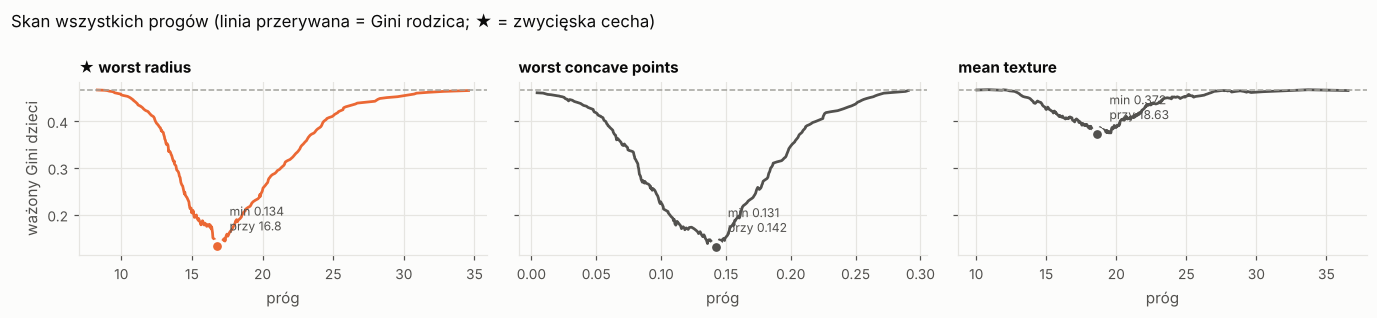

In [6]:
# Jak wygląda „poszukiwanie progu”? Pełny skan dla kilku cech na całym zbiorze treningowym
feats = [names.index(f) for f in ["worst radius", "worst concave points", "mean texture"]]
plot_gini_scan(X_train, y_train, feats, names, chosen=feats[0],
               parent_gini=float(gini(np.bincount(y_train))));

## 4. Drzewo decyzyjne CART

Algorytm rekurencyjny dla każdego węzła:
1. **Warunek stopu?** (max głębokość, węzeł czysty, za mało próbek) → liść.
2. **Losuj** `max_features` cech (w zwykłym drzewie: wszystkie).
3. Dla każdej wylosowanej cechy znajdź **najlepszy próg**.
4. Wybierz cechę z **największym spadkiem Gini**, podziel dane, powtórz dla dzieci.

Każdy krok trafia do dziennika (`node_split`, `leaf`).

In [7]:
@dataclass
class Node:
    id: int
    depth: int
    n: int                       # liczba próbek (z powtórzeniami bootstrapu)
    counts: np.ndarray           # liczności klas w węźle
    impurity: float              # Gini węzła
    feature: int = -1            # -1 oznacza liść
    threshold: float = float("nan")
    left: int = -1
    right: int = -1
    gain: float = 0.0            # spadek Gini osiągnięty przez podział
    leaf_reason: str = ""

    @property
    def is_leaf(self):
        return self.feature < 0

    @property
    def proba(self):
        return self.counts / self.counts.sum()


class DecisionTree:
    """Klasyfikator CART z losowaniem podzbioru cech w każdym węźle.

    max_features: None (wszystkie cechy – klasyczne drzewo), "sqrt", "log2",
                  liczba całkowita albo ułamek (0–1).
    """

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1,
                 max_features=None, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state

    # -- ile cech losujemy w każdym węźle ---------------------------------
    def _n_features_to_try(self, d):
        mf = self.max_features
        if mf is None:
            return d
        if mf == "sqrt":
            return max(1, int(np.sqrt(d)))
        if mf == "log2":
            return max(1, int(np.log2(d)))
        if isinstance(mf, float):
            return max(1, int(mf * d))
        return max(1, min(d, int(mf)))

    # -- trening -----------------------------------------------------------
    def fit(self, X, y, n_classes=None, tracer=None, tree_id=0, feature_names=None):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        self.rng_ = np.random.default_rng(self.random_state)
        self.n_classes_ = n_classes or int(y.max()) + 1
        self.n_features_ = X.shape[1]
        self.feature_names_ = list(feature_names) if feature_names is not None \
            else [f"x{j}" for j in range(self.n_features_)]
        self.tree_id_ = tree_id
        self.nodes_ = []
        self._n_root = len(y)
        self._tracer = tracer
        self._detail = tracer is not None and tracer.wants_detail(tree_id)

        self._grow(X, y, depth=0)

        self._tracer = None                      # nie trzymamy referencji
        self._compile()
        self._compute_importances()
        return self

    def _grow(self, X, y, depth):
        counts = np.bincount(y, minlength=self.n_classes_)
        node = Node(id=len(self.nodes_), depth=depth, n=len(y),
                    counts=counts, impurity=float(gini(counts)))
        self.nodes_.append(node)

        # 1) Czy w ogóle próbujemy dzielić?
        reason = None
        if self.max_depth is not None and depth >= self.max_depth:
            reason = "osiągnięto max_depth"
        elif node.impurity == 0.0:
            reason = "węzeł czysty (jedna klasa)"
        elif node.n < self.min_samples_split:
            reason = "za mało próbek (min_samples_split)"

        candidates, best = [], None
        if reason is None:
            # 2) Losujemy podzbiór cech – serce „random” w Random Forest
            k = self._n_features_to_try(self.n_features_)
            feats = self.rng_.choice(self.n_features_, size=k, replace=False)

            # 3) Dla każdej wylosowanej cechy szukamy najlepszego progu
            for f in feats:
                res = best_split_for_feature(X[:, f], y, self.n_classes_,
                                             self.min_samples_leaf)
                cand = {"feature": int(f), "name": self.feature_names_[f]}
                if res is None:
                    cand.update(threshold=None, child_gini=None, gain=None)
                else:
                    thr, w = res
                    cand.update(threshold=thr, child_gini=w, gain=node.impurity - w)
                candidates.append(cand)

            # 4) Wygrywa cecha z największym spadkiem Gini
            valid = [c for c in candidates if c["gain"] is not None and c["gain"] > 1e-12]
            if valid:
                best = max(valid, key=lambda c: c["gain"])
            else:
                reason = "żadna wylosowana cecha nie poprawia Gini"

        # --- liść -----------------------------------------------------------
        if best is None:
            node.leaf_reason = reason
            if self._tracer is not None:
                self._tracer.log(
                    "leaf", tree_id=self.tree_id_, node_id=node.id, depth=depth,
                    n=node.n, counts=counts, gini=node.impurity,
                    proba=node.proba, reason=reason)
            return node.id

        # --- podział --------------------------------------------------------
        f, thr = best["feature"], best["threshold"]
        mask = X[:, f] <= thr
        node.feature, node.threshold, node.gain = f, thr, best["gain"]

        if self._tracer is not None:
            rec = dict(
                tree_id=self.tree_id_, node_id=node.id, depth=depth, n=node.n,
                counts=counts, gini=node.impurity,
                feature=f, name=best["name"], threshold=thr, gain=best["gain"],
                weighted_gain=node.n / self._n_root * best["gain"],
                n_left=int(mask.sum()), n_right=int((~mask).sum()),
                n_candidates=len(candidates))
            if self._detail:
                rec["candidates"] = sorted(
                    candidates, key=lambda c: -1 if c["gain"] is None else -c["gain"])
            self._tracer.log("node_split", **rec)

        node.left = self._grow(X[mask], y[mask], depth + 1)
        node.right = self._grow(X[~mask], y[~mask], depth + 1)
        return node.id

    # -- struktury tablicowe do szybkiej predykcji ------------------------
    def _compile(self):
        self._feature = np.array([nd.feature for nd in self.nodes_])
        self._threshold = np.array([nd.threshold for nd in self.nodes_])
        self._left = np.array([nd.left for nd in self.nodes_])
        self._right = np.array([nd.right for nd in self.nodes_])
        self._value = np.array([nd.proba for nd in self.nodes_])
        self._parent = np.full(len(self.nodes_), -1)
        for nd in self.nodes_:
            if not nd.is_leaf:
                self._parent[nd.left] = self._parent[nd.right] = nd.id
        self.depth_ = max(nd.depth for nd in self.nodes_)
        self.n_leaves_ = int((self._feature < 0).sum())

    def _compute_importances(self):
        """MDI: suma ważonych spadków Gini, w których brała udział cecha."""
        imp = np.zeros(self.n_features_)
        for nd in self.nodes_:
            if not nd.is_leaf:
                imp[nd.feature] += nd.n * nd.gain
        imp /= self._n_root
        s = imp.sum()
        self.feature_importances_ = imp / s if s > 0 else imp

    # -- predykcja ---------------------------------------------------------
    def apply(self, X):
        """Indeks liścia, do którego trafia każda próbka."""
        X = np.asarray(X, dtype=float)
        ids = np.zeros(len(X), dtype=int)
        rows = np.arange(len(X))
        while True:
            feat = self._feature[ids]
            leaf = feat < 0
            if leaf.all():
                return ids
            go_left = X[rows, np.where(leaf, 0, feat)] <= self._threshold[ids]
            nxt = np.where(go_left, self._left[ids], self._right[ids])
            ids = np.where(leaf, ids, nxt)

    def predict_proba(self, X):
        return self._value[self.apply(X)]

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

    def decision_path(self, x):
        """Lista węzłów (od korzenia do liścia) odwiedzonych przez próbkę x."""
        path, i = [0], 0
        while self._feature[i] >= 0:
            i = self._left[i] if x[self._feature[i]] <= self._threshold[i] else self._right[i]
            path.append(int(i))
        return path

    def node_mask(self, X, node_id):
        """Które wiersze X docierają do węzła node_id (odtwarzamy warunki ścieżki)."""
        chain = []
        i = node_id
        while self._parent[i] >= 0:
            chain.append(i)
            i = self._parent[i]
        mask = np.ones(len(X), dtype=bool)
        for child in reversed(chain):
            par = self._parent[child]
            le = X[:, self._feature[par]] <= self._threshold[par]
            mask &= le if child == self._left[par] else ~le
        return mask

    def explain_path(self, x, cls=1):
        """Ścieżka próbki x z opisem każdego kroku i zmianą P(klasa=cls)."""
        steps = []
        path = self.decision_path(x)
        for parent, child in zip(path[:-1], path[1:]):
            f = int(self._feature[parent])
            steps.append({
                "node_id": parent, "feature": f, "name": self.feature_names_[f],
                "value": float(x[f]), "threshold": float(self._threshold[parent]),
                "go_left": bool(x[f] <= self._threshold[parent]),
                "p_before": float(self._value[parent][cls]),
                "p_after": float(self._value[child][cls]),
            })
        return steps, int(path[-1])

### 4.1 Pojedyncze drzewo z pełnym śladem i porównanie ze scikit-learn
Jeśli implementacja jest poprawna, klasyczne drzewo (wszystkie cechy w każdym węźle) powinno mieć **tę samą strukturę** co `DecisionTreeClassifier`: liczbę węzłów, głębokość, cechę w korzeniu i ważności cech. Pojedyncze różnice predykcji wynikają z remisów: przy równych zyskach Gini sklearn losuje kolejność cech, a my bierzemy pierwszą.

In [8]:
from sklearn.tree import DecisionTreeClassifier

tr_tree = Tracer(detail_trees=[0])
tree = DecisionTree(max_features=None).fit(X_train, y_train, tracer=tr_tree, feature_names=names)
sk_tree = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)

print("liczba węzłów   nasze / sklearn:", len(tree.nodes_), "/", sk_tree.tree_.node_count)
print("głębokość       nasze / sklearn:", tree.depth_, "/", sk_tree.get_depth())
print("cecha w korzeniu nasze / sklearn:", names[tree.nodes_[0].feature], "/", names[sk_tree.tree_.feature[0]])
print("zgodność predykcji na teście:   ", (tree.predict(X_test) == sk_tree.predict(X_test)).mean())
print("korelacja ważności cech:        ", np.corrcoef(tree.feature_importances_, sk_tree.feature_importances_)[0, 1].round(5))
print("\nzdarzenia w dzienniku:", tr_tree.counts())

liczba węzłów   nasze / sklearn: 39 / 39
głębokość       nasze / sklearn: 7 / 7
cecha w korzeniu nasze / sklearn: worst concave points / worst concave points
zgodność predykcji na teście:    1.0
korelacja ważności cech:         0.99959

zdarzenia w dzienniku: {'node_split': 19, 'leaf': 20}


**Dziennik pierwszej decyzji (korzeń)** — w surowej postaci JSON i jako zdanie:

In [9]:
root_event = tr_tree.filter("node_split", node_id=0)[0]
print(json.dumps({k: v for k, v in root_event.items() if k != "candidates"}, ensure_ascii=False, indent=1))
print("\nkandydaci (5 najlepszych z 30):")
pd.DataFrame(root_event["candidates"])[["name", "threshold", "child_gini", "gain"]].head()

{
 "seq": 0,
 "event": "node_split",
 "tree_id": 0,
 "node_id": 0,
 "depth": 0,
 "n": 427,
 "counts": [
  268,
  159
 ],
 "gini": 0.467419,
 "feature": 27,
 "name": "worst concave points",
 "threshold": 0.142,
 "gain": 0.336862,
 "weighted_gain": 0.336862,
 "n_left": 280,
 "n_right": 147,
 "n_candidates": 30
}

kandydaci (5 najlepszych z 30):


,name,threshold,child_gini,gain
0,worst concave points,0.14200,0.130557,0.336862
1,worst perimeter,115.35000,0.131704,0.335715
2,mean concave points,0.05142,0.131859,0.335560
3,worst area,884.75000,0.132914,0.334505
4,worst radius,16.79500,0.133795,0.333624


In [10]:
def explain_node_text(event):
    """Opis zdarzenia node_split zrozumiały dla człowieka."""
    lines = [
        f"Drzewo {event['tree_id']}, węzeł {event['node_id']} (głębokość {event['depth']}): "
        f"{event['n']} próbek, łagodne/złośliwe = {event['counts'][0]}/{event['counts'][1]}, "
        f"Gini = {event['gini']:.3f}."]
    cands = event.get("candidates")
    if cands:
        names = ", ".join(c["name"] for c in cands[:6])
        if len(cands) > 6:
            names += f" i {len(cands) - 6} innych"
        lines.append(f"Sprawdzono {len(cands)} cech-kandydatek (od najlepszej): {names}.")
        valid = [c for c in cands if c["gain"] is not None]
        if len(valid) > 1:
            second = valid[1]
            lines.append(
                f"Wygrała „{event['name']}” z progiem {event['threshold']:.4g}: spadek Gini "
                f"{event['gain']:.4f}. Druga była „{second['name']}” "
                f"({second['gain']:.4f}).")
        else:
            lines.append(f"Wygrała „{event['name']}” z progiem {event['threshold']:.4g}.")
    else:
        lines.append(f"Podział: {event['name']} ≤ {event['threshold']:.4g} "
                     f"(spadek Gini {event['gain']:.4f}).")
    lines.append(f"Na lewo trafia {event['n_left']} próbek, na prawo {event['n_right']}.")
    return " ".join(lines)


print(explain_node_text(root_event))

Drzewo 0, węzeł 0 (głębokość 0): 427 próbek, łagodne/złośliwe = 268/159, Gini = 0.467. Sprawdzono 30 cech-kandydatek (od najlepszej): worst concave points, worst perimeter, mean concave points, worst area, worst radius, mean perimeter i 24 innych. Wygrała „worst concave points” z progiem 0.142: spadek Gini 0.3369. Druga była „worst perimeter” (0.3357). Na lewo trafia 280 próbek, na prawo 147.


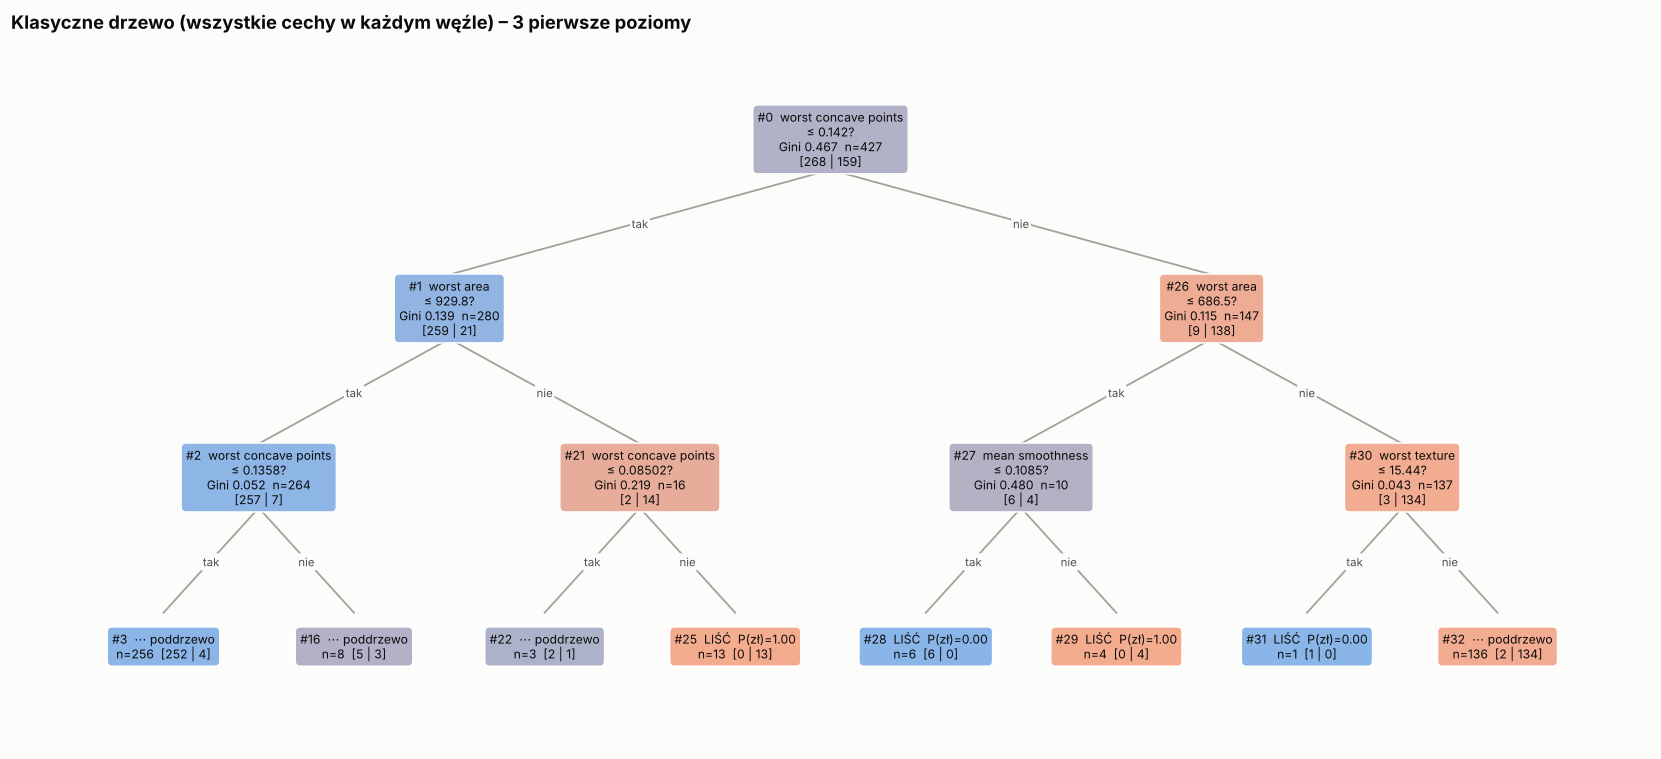

In [11]:
plot_tree(tree, names, max_depth=3, title="Klasyczne drzewo (wszystkie cechy w każdym węźle) – 3 pierwsze poziomy");

In [12]:
# Dlaczego węzły przestały się dzielić?
pd.Series([e["reason"] for e in tr_tree.filter("leaf")]).value_counts()

węzeł czysty (jedna klasa)    20
Name: count, dtype: int64

## 5. Problem: pojedyncze drzewo jest niestabilne

Uczymy to samo drzewo na **lekko zmienionych danych** (kolejne próbki bootstrap) i patrzymy, co trafia do korzenia i jak zmienia się dokładność. Duża wariancja = model, któremu trudno ufać. To jest główna motywacja dla lasu.

In [13]:
def single_tree_stability(X, y, X_test, y_test, feature_names, n_runs=30,
                          max_depth=None, random_state=0):
    """Jak bardzo zmienia się POJEDYNCZE drzewo, gdy lekko zmienią się dane?

    Uczymy klasyczne drzewo (wszystkie cechy w każdym węźle) na kolejnych
    próbkach bootstrap i zapisujemy cechę w korzeniu, cechy z poziomu 1
    i dokładność na teście.
    """
    rng = np.random.default_rng(random_state)
    n = len(y)
    out = []
    for r in range(n_runs):
        idx = rng.integers(0, n, n)
        t = DecisionTree(max_depth=max_depth, max_features=None,
                         random_state=int(rng.integers(2**31 - 1))).fit(X[idx], y[idx])
        root = t.nodes_[0]
        lvl1 = [feature_names[t.nodes_[c].feature] for c in (root.left, root.right)
                if c >= 0 and not t.nodes_[c].is_leaf]
        out.append({"run": r, "root": feature_names[root.feature],
                    "root_threshold": root.threshold, "level1": lvl1,
                    "n_leaves": t.n_leaves_, "depth": t.depth_,
                    "test_accuracy": float((t.predict(X_test) == y_test).mean())})
    return out


stab = single_tree_stability(X_train, y_train, X_test, y_test, names, n_runs=30)
stab_df = pd.DataFrame(stab)
print("cecha w korzeniu:", stab_df["root"].value_counts().to_dict())
print(f"dokładność pojedynczego drzewa na teście: średnio {stab_df.test_accuracy.mean():.3f}, "
      f"min {stab_df.test_accuracy.min():.3f}, max {stab_df.test_accuracy.max():.3f}, "
      f"odch. std {stab_df.test_accuracy.std():.3f}")
stab_df.head(8)

cecha w korzeniu: {'worst perimeter': 12, 'mean concave points': 8, 'worst concave points': 8, 'worst area': 2}
dokładność pojedynczego drzewa na teście: średnio 0.904, min 0.859, max 0.937, odch. std 0.018


,run,root,root_threshold,level1,n_leaves,depth,test_accuracy
0,0,mean concave points,0.05593,"[symmetry error, worst perimeter]",11,4,0.894366
1,1,mean concave points,0.05581,"[worst area, mean texture]",13,6,0.908451
2,2,worst perimeter,112.60000,"[worst concave points, mean concavity]",11,6,0.929577
3,3,mean concave points,0.05142,"[mean area, worst perimeter]",15,7,0.922535
4,4,worst concave points,0.14895,"[worst perimeter, worst radius]",16,7,0.887324
5,5,worst perimeter,112.80000,"[worst compactness, worst radius]",10,6,0.894366
6,6,worst concave points,0.14205,"[worst area, worst area]",11,6,0.908451
7,7,mean concave points,0.05174,"[mean area, worst perimeter]",14,6,0.880282


## 6. Random Forest

Dwa źródła losowości, które **dekorelują** drzewa:
1. **Bootstrap** — każde drzewo uczy się na $n$ próbkach losowanych ze zwracaniem. Ok. $e^{-1} \approx 36{,}8\%$ próbek nie trafia do próbki → to zbiór **OOB** (*out-of-bag*), darmowy zbiór walidacyjny dla tego drzewa.
2. **Losowy podzbiór cech w każdym węźle** — domyślnie $\lfloor\sqrt{30}\rfloor = 5$ cech. Silna cecha nie może zdominować wszystkich drzew.

Predykcja: **średnia prawdopodobieństw** drzew (głosowanie miękkie, jak w scikit-learn); dodatkowo liczymy głosy twarde.

In [14]:
class RandomForest:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, max_features="sqrt", bootstrap=True,
                 random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state

    def get_params(self):
        return {k: getattr(self, k) for k in (
            "n_estimators", "max_depth", "min_samples_split", "min_samples_leaf",
            "max_features", "bootstrap", "random_state")}

    # ------------------------------------------------------------------
    def fit(self, X, y, feature_names=None, tracer=None, progress=None):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        n, d = X.shape
        C = int(y.max()) + 1
        rng = np.random.default_rng(self.random_state)

        self.n_classes_ = C
        self.n_features_ = d
        self.feature_names_ = list(feature_names) if feature_names is not None \
            else [f"x{j}" for j in range(d)]
        self.X_train_, self.y_train_ = X, y
        self.trees_ = []
        self.inbag_counts_ = np.zeros((self.n_estimators, n), dtype=np.int16)
        self.oob_curve_ = []                    # (liczba drzew, błąd OOB, pokrycie)
        oob_sum = np.zeros((n, C))
        oob_n = np.zeros(n)

        if tracer:
            tracer.log("forest_start", params=self.get_params(), n_samples=n,
                       n_features=d, class_counts=np.bincount(y, minlength=C),
                       features_per_split=DecisionTree(max_features=self.max_features)
                       ._n_features_to_try(d))

        for t in range(self.n_estimators):
            # 1) BOOTSTRAP: losujemy n próbek ZE ZWRACANIEM
            idx = rng.integers(0, n, n) if self.bootstrap else np.arange(n)
            inbag = np.bincount(idx, minlength=n)
            oob = np.flatnonzero(inbag == 0)        # próbki, których drzewo nie widziało
            self.inbag_counts_[t] = inbag

            if tracer:
                rec = dict(tree_id=t, n_drawn=n, n_unique=int((inbag > 0).sum()),
                           frac_unique=float((inbag > 0).mean()), n_oob=len(oob),
                           max_repeats=int(inbag.max()))
                if tracer.wants_detail(t):
                    rec["oob_indices"] = oob
                    rec["repeat_hist"] = np.bincount(inbag)
                tracer.log("bootstrap", **rec)

            # 2) DRZEWO uczone na próbce bootstrap
            tree = DecisionTree(max_depth=self.max_depth,
                                min_samples_split=self.min_samples_split,
                                min_samples_leaf=self.min_samples_leaf,
                                max_features=self.max_features,
                                random_state=int(rng.integers(2**31 - 1)))
            tree.fit(X[idx], y[idx], n_classes=C, tracer=tracer, tree_id=t,
                     feature_names=self.feature_names_)
            self.trees_.append(tree)

            # 3) OOB: drzewo ocenia próbki, których nie widziało
            tree_oob_acc = None
            if len(oob):
                p = tree.predict_proba(X[oob])
                oob_sum[oob] += p
                oob_n[oob] += 1
                tree_oob_acc = float((p.argmax(1) == y[oob]).mean())
            covered = oob_n > 0
            oob_err = float((oob_sum[covered].argmax(1) != y[covered]).mean()) \
                if covered.any() else float("nan")
            self.oob_curve_.append((t + 1, oob_err, float(covered.mean())))

            if tracer:
                root = tree.nodes_[0]
                tracer.log("tree_done", tree_id=t, n_nodes=len(tree.nodes_),
                           n_leaves=tree.n_leaves_, depth=tree.depth_,
                           root_feature=None if root.is_leaf else self.feature_names_[root.feature],
                           root_threshold=None if root.is_leaf else root.threshold,
                           tree_oob_accuracy=tree_oob_acc)
                tracer.log("oob_progress", n_trees=t + 1, oob_error=oob_err,
                           oob_coverage=float(covered.mean()))
            if progress:
                progress(t + 1, self.n_estimators)

        with np.errstate(invalid="ignore", divide="ignore"):
            self.oob_decision_function_ = oob_sum / oob_n[:, None]
        self.oob_score_ = 1.0 - self.oob_curve_[-1][1]

        imp = np.mean([tr.feature_importances_ for tr in self.trees_], axis=0)
        self.feature_importances_ = imp / imp.sum()

        if tracer:
            tracer.log("forest_done", n_trees=self.n_estimators,
                       oob_score=self.oob_score_,
                       mean_depth=float(np.mean([tr.depth_ for tr in self.trees_])),
                       mean_leaves=float(np.mean([tr.n_leaves_ for tr in self.trees_])))
        return self

    # ------------------------------------------------------------------
    def tree_probas(self, X):
        """Prawdopodobieństwa z KAŻDEGO drzewa osobno: (n_drzew, n_próbek, n_klas)."""
        return np.stack([t.predict_proba(X) for t in self.trees_])

    def predict_proba(self, X):
        """Głosowanie miękkie (jak w sklearn): średnia prawdopodobieństw drzew."""
        return self.tree_probas(X).mean(axis=0)

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

    def hard_votes(self, X):
        """Głosowanie twarde: ile drzew wskazało każdą klasę."""
        preds = self.tree_probas(X).argmax(axis=2)       # (T, n)
        return np.stack([(preds == c).sum(0) for c in range(self.n_classes_)], axis=1)

    def predict_logged(self, x, tracer, sample_id=None, cls=1):
        """Predykcja jednej próbki z zapisem głosów każdego drzewa do logu."""
        x = np.asarray(x, dtype=float)
        tp = self.tree_probas(x[None, :])[:, 0, :]           # (T, C)
        proba = tp.mean(0)
        votes = np.bincount(tp.argmax(1), minlength=self.n_classes_)
        tracer.log("predict", sample_id=sample_id, proba=proba,
                   predicted=int(proba.argmax()), hard_votes=votes,
                   per_tree_p=tp[:, cls],
                   vote_margin=float(abs(votes[1] - votes[0]) / len(self.trees_))
                   if self.n_classes_ == 2 else None)
        return proba

In [15]:
tracer = Tracer(path="rf_trace.jsonl", detail_trees=[0, 1, 2])
rf = RandomForest(n_estimators=100, max_features="sqrt", random_state=0)
rf.fit(X_train, y_train, feature_names=names, tracer=tracer)

print("zdarzenia w dzienniku:", tracer.counts())
print(f"dokładność OOB: {rf.oob_score_:.4f}")
print("dziennik zapisany do rf_trace.jsonl")

zdarzenia w dzienniku: {'forest_start': 1, 'bootstrap': 100, 'node_split': 1546, 'leaf': 1646, 'tree_done': 100, 'oob_progress': 100, 'forest_done': 1}
dokładność OOB: 0.9602
dziennik zapisany do rf_trace.jsonl


### 6.1 Bootstrap pod lupą

,tree_id,n_unique,frac_unique,n_oob,max_repeats
0,0,275,0.644028,152,5
1,1,277,0.648712,150,5
2,2,276,0.646370,151,5
3,3,267,0.625293,160,5
4,4,268,0.627635,159,6


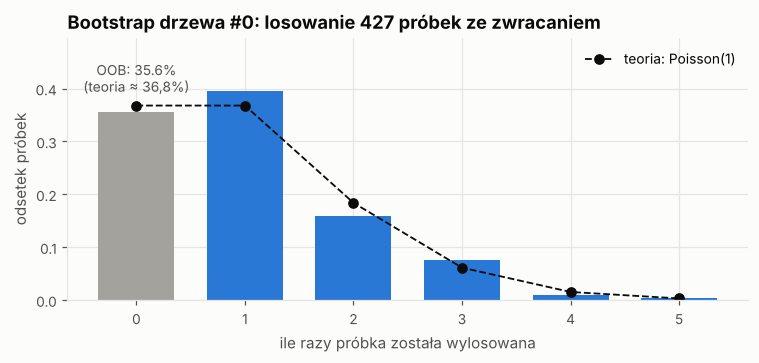

In [16]:
display(pd.DataFrame(tracer.filter("bootstrap"))[["tree_id", "n_unique", "frac_unique", "n_oob", "max_repeats"]].head())
plot_bootstrap(rf.inbag_counts_, tree_id=0);

### 6.2 Ta sama decyzja w korzeniu — trzy różne drzewa
Każde drzewo widzi inną próbkę i **inne wylosowane cechy**. Porównaj kandydatów w korzeniach drzew 0, 1 i 2.

Drzewo 0, węzeł 0 (głębokość 0): 427 próbek, łagodne/złośliwe = 275/152, Gini = 0.459. Sprawdzono 5 cech-kandydatek (od najlepszej): worst radius, worst concave points, mean compactness, concavity error, texture error. Wygrała „worst radius” z progiem 17.02: spadek Gini 0.3375. Druga była „worst concave points” (0.3364). Na lewo trafia 297 próbek, na prawo 130. 



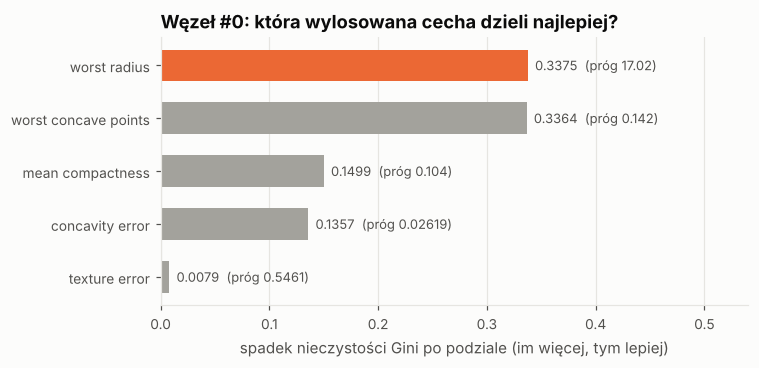

Drzewo 1, węzeł 0 (głębokość 0): 427 próbek, łagodne/złośliwe = 277/150, Gini = 0.456. Sprawdzono 5 cech-kandydatek (od najlepszej): worst radius, mean radius, worst concavity, mean smoothness, symmetry error. Wygrała „worst radius” z progiem 17.02: spadek Gini 0.3260. Druga była „mean radius” (0.2955). Na lewo trafia 297 próbek, na prawo 130. 



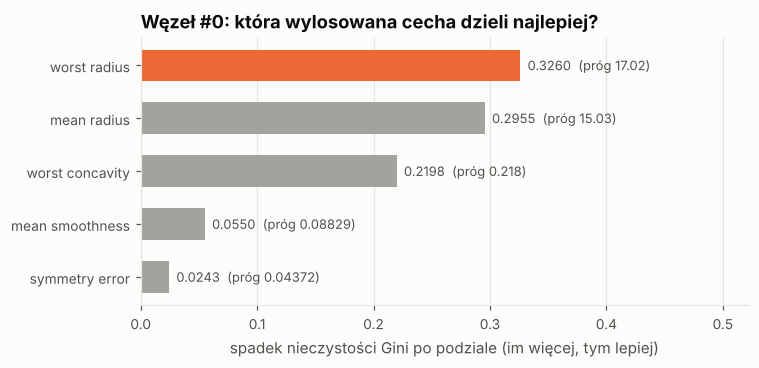

Drzewo 2, węzeł 0 (głębokość 0): 427 próbek, łagodne/złośliwe = 289/138, Gini = 0.437. Sprawdzono 5 cech-kandydatek (od najlepszej): worst concavity, perimeter error, mean compactness, concavity error, fractal dimension error. Wygrała „worst concavity” z progiem 0.2591: spadek Gini 0.2211. Druga była „perimeter error” (0.1956). Na lewo trafia 253 próbek, na prawo 174. 



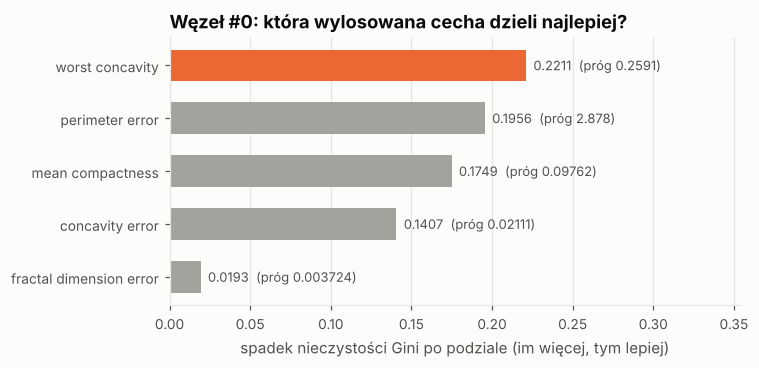

In [17]:
for t in [0, 1, 2]:
    ev = tracer.filter("node_split", tree_id=t, node_id=0)[0]
    print(explain_node_text(ev), "\n")
    plot_split_candidates(ev); plt.show()

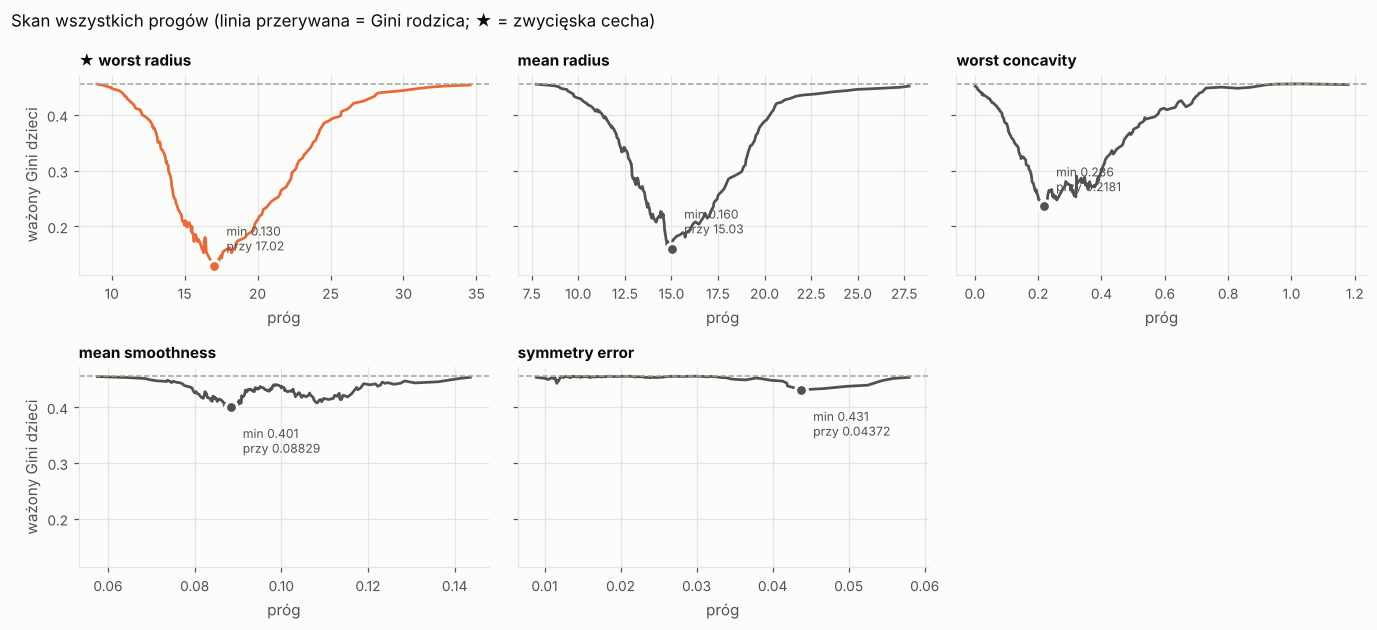

In [18]:
def node_data(forest, tree_id, node_id):
    """Odtwarza dane, które drzewo „widziało” w danym węźle.

    Próbka bootstrap = wiersze treningowe powtórzone tyle razy, ile razy
    zostały wylosowane (inbag_counts_), potem filtr warunkami ścieżki.
    """
    tree = forest.trees_[tree_id]
    rep = forest.inbag_counts_[tree_id]
    Xb = np.repeat(forest.X_train_, rep, axis=0)
    yb = np.repeat(forest.y_train_, rep)
    m = tree.node_mask(Xb, node_id)
    return Xb[m], yb[m]


# Pełny skan progów dla wszystkich kandydatów w korzeniu drzewa 1 – na danych, które to drzewo naprawdę widziało
ev = tracer.filter("node_split", tree_id=1, node_id=0)[0]
Xn, yn = node_data(rf, 1, 0)
plot_gini_scan(Xn, yn, [c["feature"] for c in ev["candidates"]], names,
               chosen=ev["feature"], parent_gini=ev["gini"]);

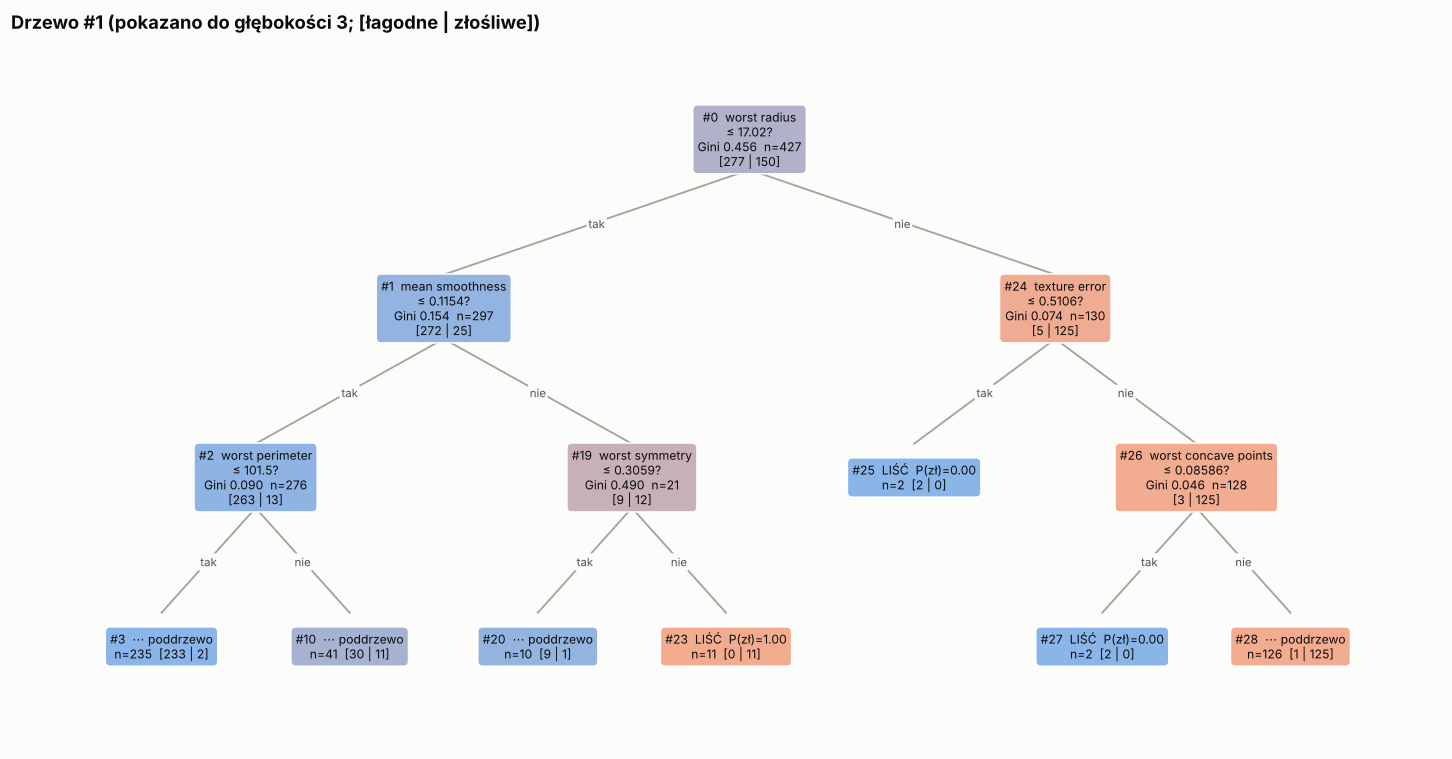

In [19]:
plot_tree(rf.trees_[1], names, max_depth=3);

### 6.3 Podsumowanie każdego drzewa z dziennika

In [20]:
trees_df = pd.DataFrame(tracer.filter("tree_done"))[
    ["tree_id", "n_nodes", "n_leaves", "depth", "root_feature", "root_threshold", "tree_oob_accuracy"]]
display(trees_df.head(10))
trees_df[["n_leaves", "depth", "tree_oob_accuracy"]].describe().T

,tree_id,n_nodes,n_leaves,depth,root_feature,root_threshold,tree_oob_accuracy
0,0,35,18,6,worst radius,17.02500,0.940789
1,1,33,17,6,worst radius,17.02500,0.900000
2,2,33,17,6,worst concavity,0.25915,0.900662
3,3,43,22,10,worst radius,17.02500,0.937500
4,4,33,17,7,worst concave points,0.14895,0.899371
5,5,29,15,7,mean area,694.50000,0.928571
6,6,23,12,6,worst concave points,0.14205,0.915033
7,7,31,16,7,mean area,681.60000,0.956250
8,8,25,13,5,worst radius,16.80500,0.943038
9,9,35,18,7,mean perimeter,96.62000,0.942675


,count,mean,std,min,25%,50%,75%,max
n_leaves,100.0,16.46000,2.675818,10.000000,14.000000,17.00000,18.000000,22.000000
depth,100.0,6.78000,1.194093,5.000000,6.000000,6.50000,7.000000,10.000000
tree_oob_accuracy,100.0,0.92708,0.020666,0.879518,0.910115,0.92715,0.941558,0.968944


## 7. Dynamika zespołu: dlaczego wiele słabszych drzew > jedno drzewo

Breiman: błąd lasu zależy od **siły** pojedynczych drzew i od **korelacji** między nimi. Drzewa w lesie są pojedynczo *słabsze* niż klasyczne drzewo (widzą mniej cech), ale **mylą się w różnych miejscach** — uśrednianie znosi ich błędy.

średnia dokładność pojedynczego drzewa z lasu: 0.904
dokładność całego lasu:                       0.944
średnia niezgoda dwóch drzew:                 0.107


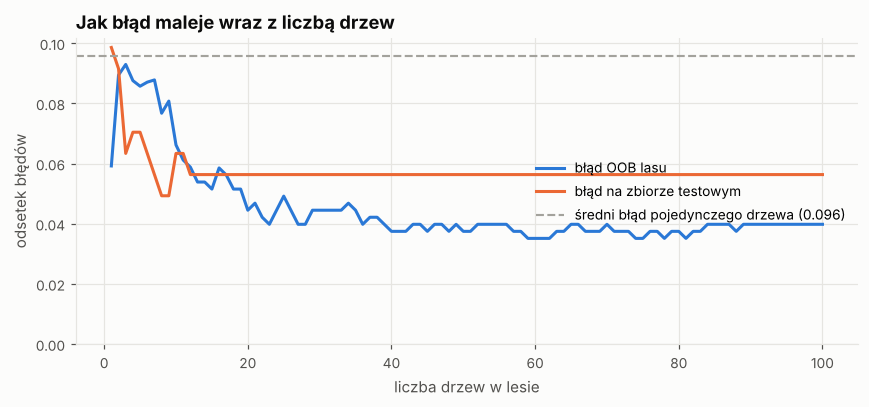

In [21]:
def accuracy_vs_n_trees(forest, X, y):
    """Dokładność lasu na teście w miarę dodawania kolejnych drzew."""
    tp = forest.tree_probas(X)                               # (T, n, C)
    cum = np.cumsum(tp, axis=0) / np.arange(1, len(tp) + 1)[:, None, None]
    return (cum.argmax(axis=2) == y[None, :]).mean(axis=1)


def tree_strength_and_correlation(forest, X, y):
    """Breiman: jakość lasu zależy od SIŁY drzew i ich KORELACJI.

    siła   – średnia dokładność pojedynczego drzewa,
    niezgoda – średni odsetek próbek, na których dwa drzewa się różnią.
    """
    preds = forest.tree_probas(X).argmax(axis=2)             # (T, n)
    acc = (preds == y[None, :]).mean(axis=1)
    T = len(preds)
    dis = np.zeros((T, T))
    for i in range(T):
        dis[i] = (preds[i][None, :] != preds).mean(axis=1)
    off = dis[~np.eye(T, dtype=bool)]
    return {"tree_accuracy": acc, "mean_tree_accuracy": float(acc.mean()),
            "disagreement_matrix": dis, "mean_disagreement": float(off.mean())}


def root_feature_counts(forest):
    """Jakie cechy trafiły do korzeni drzew w lesie (efekt losowania cech)."""
    c = {}
    for t in forest.trees_:
        r = t.nodes_[0]
        if not r.is_leaf:
            name = forest.feature_names_[r.feature]
            c[name] = c.get(name, 0) + 1
    return dict(sorted(c.items(), key=lambda kv: -kv[1]))


acc_curve = accuracy_vs_n_trees(rf, X_test, y_test)
sc = tree_strength_and_correlation(rf, X_test, y_test)
print(f"średnia dokładność pojedynczego drzewa z lasu: {sc['mean_tree_accuracy']:.3f}")
print(f"dokładność całego lasu:                       {acc_curve[-1]:.3f}")
print(f"średnia niezgoda dwóch drzew:                 {sc['mean_disagreement']:.3f}")
plot_oob_curve(rf, acc_curve, single_tree_err=1 - sc["mean_tree_accuracy"]);

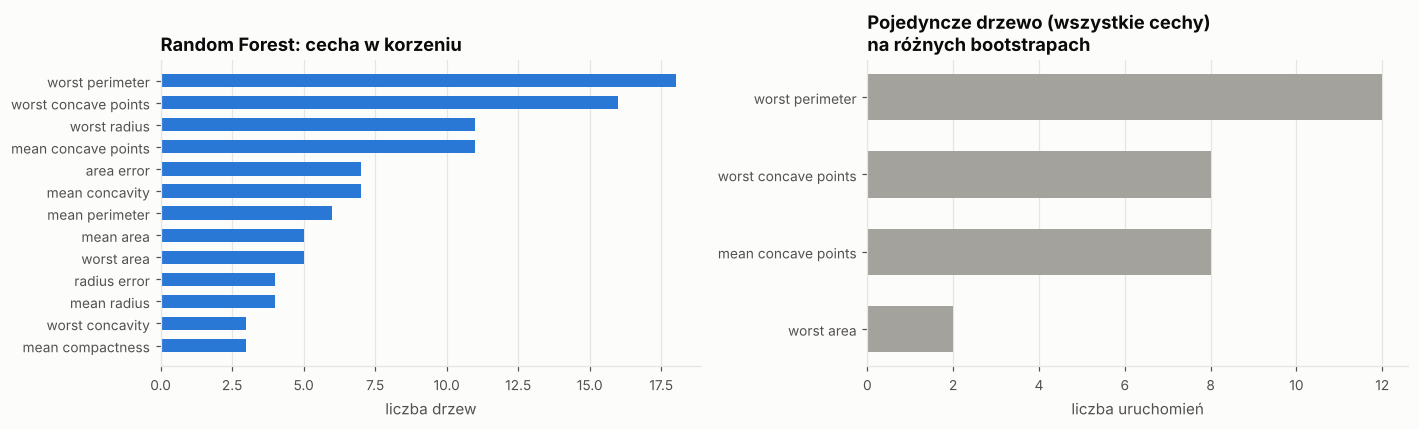

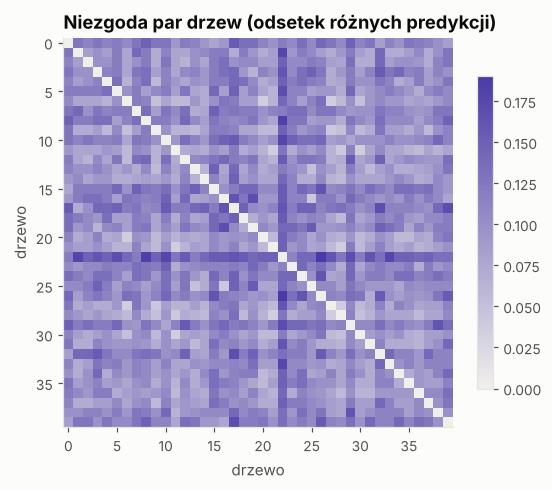

In [22]:
plot_root_features(root_feature_counts(rf), stab);
plot_disagreement(sc["disagreement_matrix"][:40, :40]);

## 8. Ocena — własne metryki i uczciwe porównanie

W diagnostyce nowotworów błędy nie są symetryczne: **przeoczony nowotwór złośliwy (FN)** jest zwykle dużo groźniejszy niż fałszywy alarm (FP). Dlatego patrzymy przede wszystkim na **czułość**, a próg decyzji traktujemy jako parametr do świadomego wyboru.

In [23]:
def confusion_matrix(y_true, y_pred, n_classes=2):
    """Wiersze = klasa prawdziwa, kolumny = klasa przewidziana."""
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def accuracy(y_true, y_pred):
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def binary_report(y_true, y_pred, pos=1):
    """Czułość (recall), precyzja, swoistość, F1 – dla klasy pozytywnej."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = int(((y_pred == pos) & (y_true == pos)).sum())
    fp = int(((y_pred == pos) & (y_true != pos)).sum())
    fn = int(((y_pred != pos) & (y_true == pos)).sum())
    tn = int(((y_pred != pos) & (y_true != pos)).sum())
    recall = tp / (tp + fn) if tp + fn else 0.0
    precision = tp / (tp + fp) if tp + fp else 0.0
    specificity = tn / (tn + fp) if tn + fp else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"accuracy": (tp + tn) / len(y_true), "recall": recall,
            "precision": precision, "specificity": specificity, "f1": f1,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn}


def roc_curve(y_true, score):
    """Krzywa ROC: przesuwamy próg od najwyższego wyniku w dół."""
    y_true = np.asarray(y_true)
    order = np.argsort(-np.asarray(score), kind="mergesort")
    s, y = np.asarray(score)[order], y_true[order]
    distinct = np.r_[np.flatnonzero(np.diff(s)), len(s) - 1]   # ostatni indeks każdej wartości
    tps = np.cumsum(y)[distinct]
    fps = (distinct + 1) - tps
    tpr = np.r_[0, tps / max(y.sum(), 1)]
    fpr = np.r_[0, fps / max((1 - y).sum(), 1)]
    thr = np.r_[np.inf, s[distinct]]
    return fpr, tpr, thr


def roc_auc(y_true, score):
    """Pole pod krzywą ROC (metoda trapezów)."""
    fpr, tpr, _ = roc_curve(y_true, score)
    return float(np.sum(np.diff(fpr) * (tpr[1:] + tpr[:-1]) / 2))


def log_loss(y_true, proba_pos, eps=1e-12):
    p = np.clip(np.asarray(proba_pos), eps, 1 - eps)
    y = np.asarray(y_true)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


def threshold_table(y_true, score, thresholds):
    """Jak zmienia się czułość/precyzja przy różnych progach decyzji."""
    rows = []
    for t in thresholds:
        r = binary_report(y_true, (np.asarray(score) >= t).astype(int))
        rows.append({"threshold": float(t), **r})
    return rows

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "RF – nasz (od podstaw)": rf.predict_proba(X_test)[:, 1],
    "RF – scikit-learn": RandomForestClassifier(100, random_state=0).fit(X_train, y_train).predict_proba(X_test)[:, 1],
    "Pojedyncze drzewo": tree.predict_proba(X_test)[:, 1],
    "Regresja logistyczna": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
                              .fit(X_train, y_train).predict_proba(X_test)[:, 1],
}
results, curves = {}, {}
for name, p in models.items():
    r = binary_report(y_test, (p >= 0.5).astype(int))
    r["auc"] = roc_auc(y_test, p)
    results[name] = r
    f, t, _ = roc_curve(y_test, p)
    curves[name] = (f, t, r["auc"])
pd.DataFrame(results).T[["accuracy", "recall", "precision", "specificity", "f1", "auc", "FN", "FP"]].round(3)

,accuracy,recall,precision,specificity,f1,auc,FN,FP
RF – nasz (od podstaw),0.944,0.906,0.941,0.966,0.923,0.981,5.0,3.0
RF – scikit-learn,0.937,0.906,0.923,0.955,0.914,0.983,5.0,4.0
Pojedyncze drzewo,0.908,0.906,0.857,0.910,0.881,0.908,5.0,8.0
Regresja logistyczna,0.958,0.925,0.961,0.978,0.942,0.995,4.0,2.0


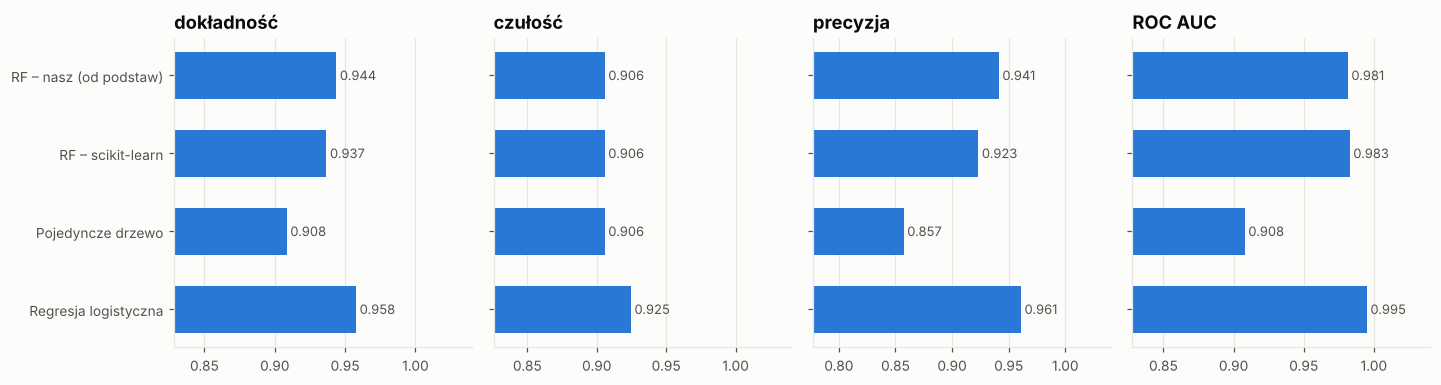

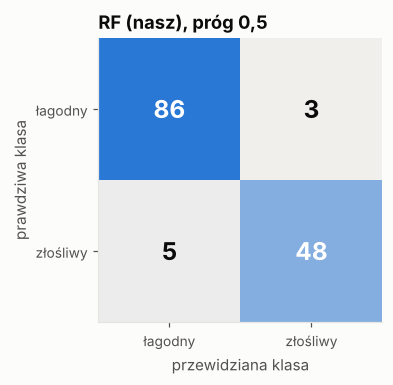

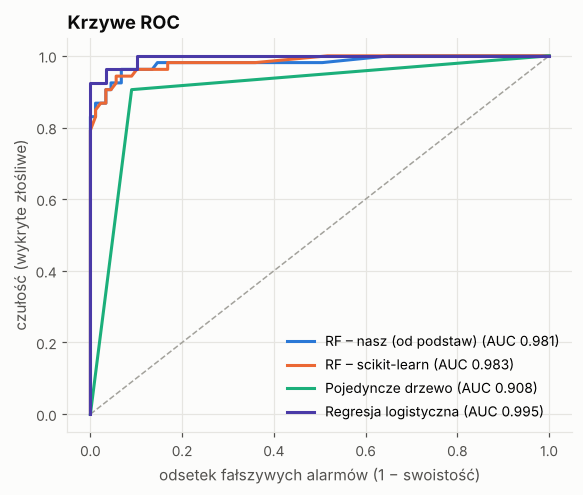

In [25]:
plot_model_comparison(results);
p_rf = models["RF – nasz (od podstaw)"]
plot_confusion(confusion_matrix(y_test, (p_rf >= 0.5).astype(int)), title="RF (nasz), próg 0,5");
plot_roc(curves);

,threshold,recall,precision,specificity,FN,FP
0,0.05,0.981,0.667,0.708,1,26
4,0.15,0.981,0.743,0.798,1,18
8,0.25,0.962,0.810,0.865,2,12
12,0.35,0.943,0.893,0.933,3,6
16,0.45,0.906,0.923,0.955,5,4
20,0.55,0.906,0.941,0.966,5,3
24,0.65,0.887,0.940,0.966,6,3
28,0.75,0.830,0.978,0.989,9,1
32,0.85,0.774,1.000,1.000,12,0
36,0.95,0.660,1.000,1.000,18,0


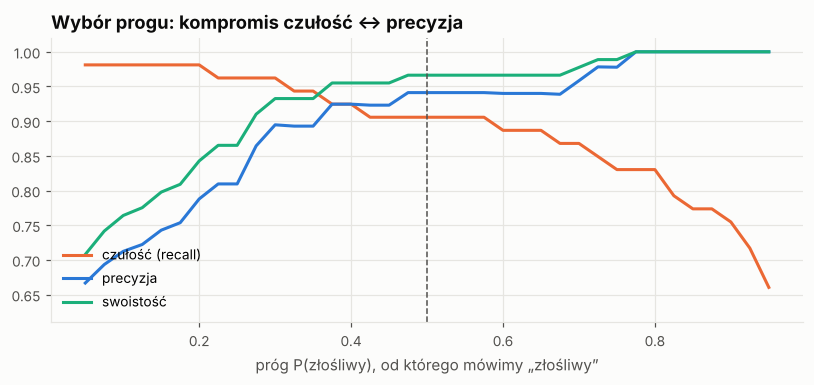

In [26]:
rows = threshold_table(y_test, p_rf, np.linspace(0.05, 0.95, 37))
plot_threshold(rows);
pd.DataFrame(rows)[["threshold", "recall", "precision", "specificity", "FN", "FP"]].iloc[::4].round(3)

,indeks testowy,prawdziwa,P(złośliwy),margines
0,10,złośliwy,0.01,-0.98
1,16,złośliwy,0.22,-0.56
2,19,złośliwy,0.32,-0.36
3,23,złośliwy,0.40,-0.20
4,24,łagodny,0.68,-0.36
5,30,złośliwy,0.35,-0.30
6,84,łagodny,0.76,-0.52
7,97,łagodny,0.70,-0.40


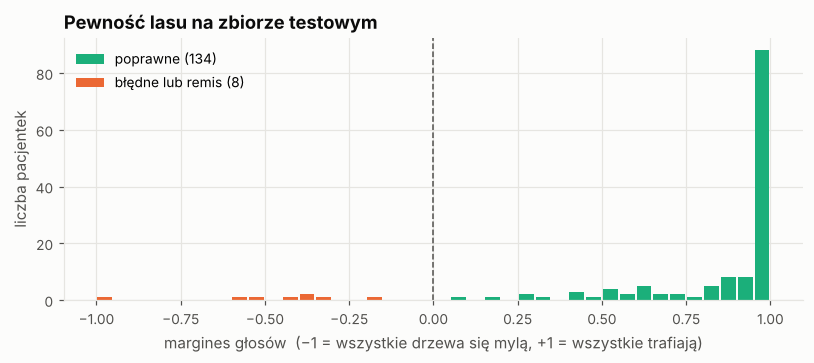

In [27]:
def vote_margins(forest, X, y):
    """Margines: (odsetek drzew za klasą prawdziwą) − (odsetek za inną klasą).

    1 = wszystkie drzewa zgodne i trafne, −1 = wszystkie zgodne i błędne,
    okolice 0 = las „waha się”.
    """
    votes = forest.hard_votes(X) / len(forest.trees_)
    rows = np.arange(len(y))
    return votes[rows, y] - votes[rows, 1 - y]


margins = vote_margins(rf, X_test, y_test)
plot_margins(margins);
wrong = np.flatnonzero((p_rf >= 0.5).astype(int) != y_test)
pd.DataFrame({"indeks testowy": wrong, "prawdziwa": [D["class_names"][c] for c in y_test[wrong]],
              "P(złośliwy)": p_rf[wrong].round(3), "margines": margins[wrong].round(2)})

## 9. Ważność globalna: które cechy decydują?

* **MDI** (*Mean Decrease in Impurity*) — suma ważonych spadków Gini przypisanych cesze. Liczymy ją **wyłącznie z dziennika** `node_split`, żeby pokazać, że log zawiera pełną informację.
* **Ważność permutacyjna OOB** (oryginalna metoda Breimana) — każde drzewo na swoich próbkach OOB: o ile spada dokładność, gdy wymieszamy wartości jednej cechy?

> **Pułapka korelacji:** `radius`, `perimeter` i `area` są niemal liniowo zależne (r ≈ 0,99). MDI rozdziela zasługę między nie dość przypadkowo, a permutacja jednej z nich niewiele szkodzi, bo pozostałe niosą tę samą informację. Ważność ≠ przyczynowość.

max różnica MDI(z logu) vs MDI(z modelu): 1.436676211052923e-07


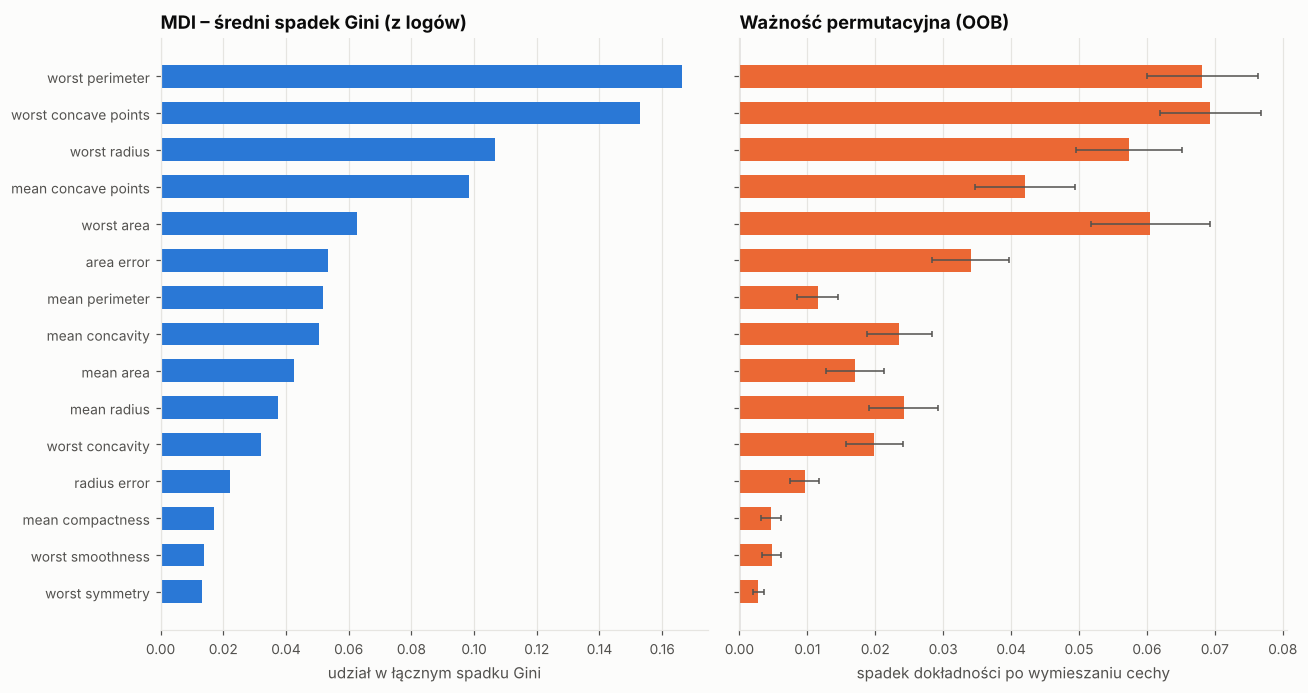

In [28]:
def mdi_from_log(tracer, n_features, n_trees):
    """To samo MDI, ale odtworzone WYŁĄCZNIE z logu zdarzeń node_split.

    Dowód, że log zawiera pełną informację o decyzjach podziału.
    """
    per_tree = np.zeros((n_trees, n_features))
    for e in tracer.filter("node_split"):
        per_tree[e["tree_id"], e["feature"]] += e["weighted_gain"]
    s = per_tree.sum(axis=1, keepdims=True)
    per_tree = np.divide(per_tree, s, out=np.zeros_like(per_tree), where=s > 0)
    imp = per_tree.mean(axis=0)
    return imp / imp.sum()


def permutation_importance_oob(forest, n_repeats=3, random_state=0):
    """Ważność permutacyjna Breimana liczona na próbkach OOB.

    Dla każdego drzewa: dokładność na jego próbkach OOB → mieszamy wartości
    jednej cechy → ponownie liczymy dokładność. Spadek = ważność cechy.
    Każde drzewo ocenia tylko dane, których NIE widziało podczas uczenia.
    """
    rng = np.random.default_rng(random_state)
    X, y = forest.X_train_, forest.y_train_
    d = X.shape[1]
    drops = np.zeros((len(forest.trees_), d))
    for t, tree in enumerate(forest.trees_):
        oob = np.flatnonzero(forest.inbag_counts_[t] == 0)
        if len(oob) < 2:
            continue
        Xo, yo = X[oob], y[oob]
        base = (tree.predict(Xo) == yo).mean()
        for j in range(d):
            acc = 0.0
            for _ in range(n_repeats):
                Xp = Xo.copy()
                Xp[:, j] = rng.permutation(Xp[:, j])
                acc += (tree.predict(Xp) == yo).mean()
            drops[t, j] = base - acc / n_repeats
    return drops.mean(axis=0), drops.std(axis=0) / np.sqrt(len(forest.trees_))


mdi_log = mdi_from_log(tracer, len(names), rf.n_estimators)
print("max różnica MDI(z logu) vs MDI(z modelu):", np.abs(mdi_log - rf.feature_importances_).max())
perm, perm_err = permutation_importance_oob(rf, n_repeats=3)
plot_importances(names, mdi_log, perm, perm_err, top_k=15);

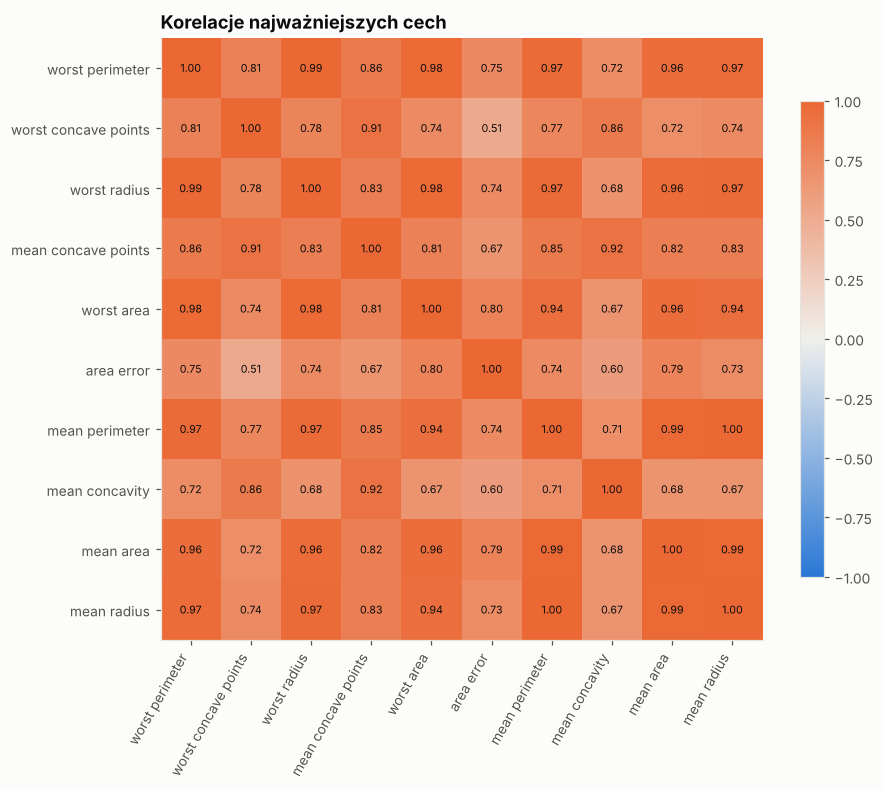

In [29]:
top = list(np.argsort(-mdi_log)[:10])
plot_correlation(X_train, names, top);

## 10. Wyjaśnienie pojedynczej predykcji

**Dekompozycja Saabasa** (*treeinterpreter*): wzdłuż ścieżki w drzewie każdy krok rodzic → dziecko zmienia $P(\text{złośliwy})$. Tę zmianę przypisujemy cesze, według której podzielono rodzica:
$$P_{\text{drzewo}}(x) = \underbrace{P(\text{korzeń})}_{\text{bias}} + \sum_{\text{kroki ścieżki}} \Delta P_{f}.$$
Uśredniając po drzewach dostajemy **dokładną** rozkładówkę predykcji lasu (bez przybliżeń):
$$P_{\text{las}}(x) = \overline{\text{bias}} + \sum_f \overline{\text{wkład}_f(x)}.$$

In [30]:
def tree_contributions(tree, x, cls=1):
    """Dla jednego drzewa: P(cls) w liściu = bias (korzeń) + Σ wkładów cech.

    Każdy krok ścieżki rodzic → dziecko zmienia P(cls); tę zmianę
    przypisujemy cesze, według której rozdzielono rodzica.
    """
    contrib = np.zeros(tree.n_features_)
    path = tree.decision_path(x)
    for parent, child in zip(path[:-1], path[1:]):
        f = tree._feature[parent]
        contrib[f] += tree._value[child][cls] - tree._value[parent][cls]
    return float(tree._value[0][cls]), contrib


def forest_contributions(forest, x, cls=1):
    """Uśredniona dekompozycja po wszystkich drzewach.

    Zwraca (bias, wkłady[cechy], wkłady_per_drzewo[T, cechy], predykcja).
    Tożsamość: bias + wkłady.sum() == forest.predict_proba(x)[cls]  (dokładnie).
    """
    x = np.asarray(x, dtype=float)
    biases, contribs = [], []
    for tree in forest.trees_:
        b, c = tree_contributions(tree, x, cls)
        biases.append(b)
        contribs.append(c)
    contribs = np.array(contribs)
    bias = float(np.mean(biases))
    total = contribs.mean(axis=0)
    return bias, total, contribs, bias + total.sum()


def path_table(forest, x, cls=1, max_trees=None):
    """Czytelne ścieżki decyzji próbki x w każdym drzewie."""
    rows = []
    for t, tree in enumerate(forest.trees_[:max_trees]):
        steps, leaf = tree.explain_path(x, cls)
        txt = " → ".join(
            f"{s['name']} {'≤' if s['go_left'] else '>'} {s['threshold']:.3g}" for s in steps)
        p = float(tree._value[leaf][cls])
        rows.append({"drzewo": t, "głos": int(p >= 0.5), "P(złośliwy)": round(p, 3),
                     "głębokość": len(steps), "ścieżka": txt})
    return rows


def explain_prediction_text(forest, x, feature_names, cls=1, top_k=4):
    """Opis predykcji: głosy drzew + najważniejsze wkłady cech."""
    bias, contrib, _, p = forest_contributions(forest, x, cls)
    votes = forest.hard_votes(np.asarray(x)[None, :])[0]
    T = len(forest.trees_)
    label = "ZŁOŚLIWY" if p >= 0.5 else "ŁAGODNY"
    order = np.argsort(-np.abs(contrib))[:top_k]
    parts = []
    for j in order:
        kier = "podnosi" if contrib[j] > 0 else "obniża"
        parts.append(f"{feature_names[j]} = {x[j]:.4g} {kier} P(złośliwy) o {abs(contrib[j]):.3f}")
    return (
        f"Las: {label}, P(złośliwy) = {p:.3f}. Głosy drzew: {votes[1]} za złośliwym, "
        f"{votes[0]} za łagodnym (z {T}). Punkt wyjścia (odsetek złośliwych w próbkach "
        f"bootstrap) = {bias:.3f}. Najsilniejsze wkłady: " + "; ".join(parts) + ".")


def explain_patient(i, n_paths=5, tree_to_draw=0):
    x = X_test[i]
    print(f"Pacjentka testowa #{i}, prawdziwa diagnoza: {D['class_names'][y_test[i]].upper()}\n")
    rf.predict_logged(x, tracer, sample_id=int(D['idx_test'][i]))
    print(explain_prediction_text(rf, x, names), "\n")
    bias, contrib, _, p = forest_contributions(rf, x)
    print(f"kontrola: bias + Σ wkładów = {p:.6f};  predict_proba = {rf.predict_proba(x[None])[0, 1]:.6f}")
    plot_tree_votes(rf.tree_probas(x[None])[:, 0, 1]); plt.show()
    plot_waterfall(bias, contrib, names, x); plt.show()
    display(pd.DataFrame(path_table(rf, x, max_trees=n_paths)))
    t = rf.trees_[tree_to_draw]
    plot_tree(t, names, max_depth=4, highlight_path=t.decision_path(x),
              title=f"Ścieżka pacjentki #{i} w drzewie #{tree_to_draw}"); plt.show()

### 10.1 Przypadek jednoznaczny

Pacjentka testowa #0, prawdziwa diagnoza: ZŁOŚLIWY

Las: ZŁOŚLIWY, P(złośliwy) = 1.000. Głosy drzew: 100 za złośliwym, 0 za łagodnym (z 100). Punkt wyjścia (odsetek złośliwych w próbkach bootstrap) = 0.370. Najsilniejsze wkłady: worst perimeter = 153.2 podnosi P(złośliwy) o 0.121; worst concave points = 0.1932 podnosi P(złośliwy) o 0.101; worst radius = 22.88 podnosi P(złośliwy) o 0.079; mean concave points = 0.074 podnosi P(złośliwy) o 0.060. 

kontrola: bias + Σ wkładów = 1.000000;  predict_proba = 1.000000


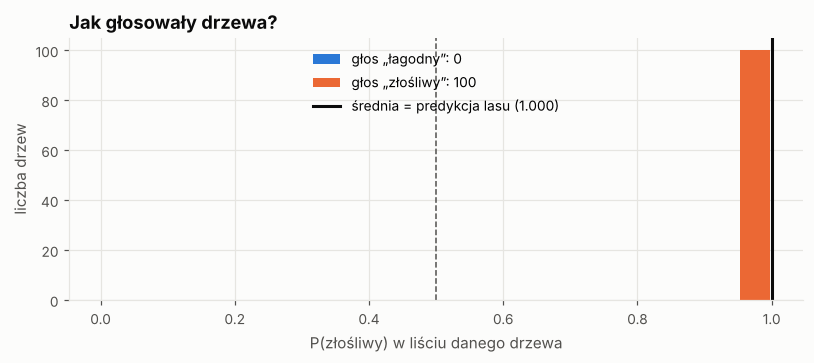

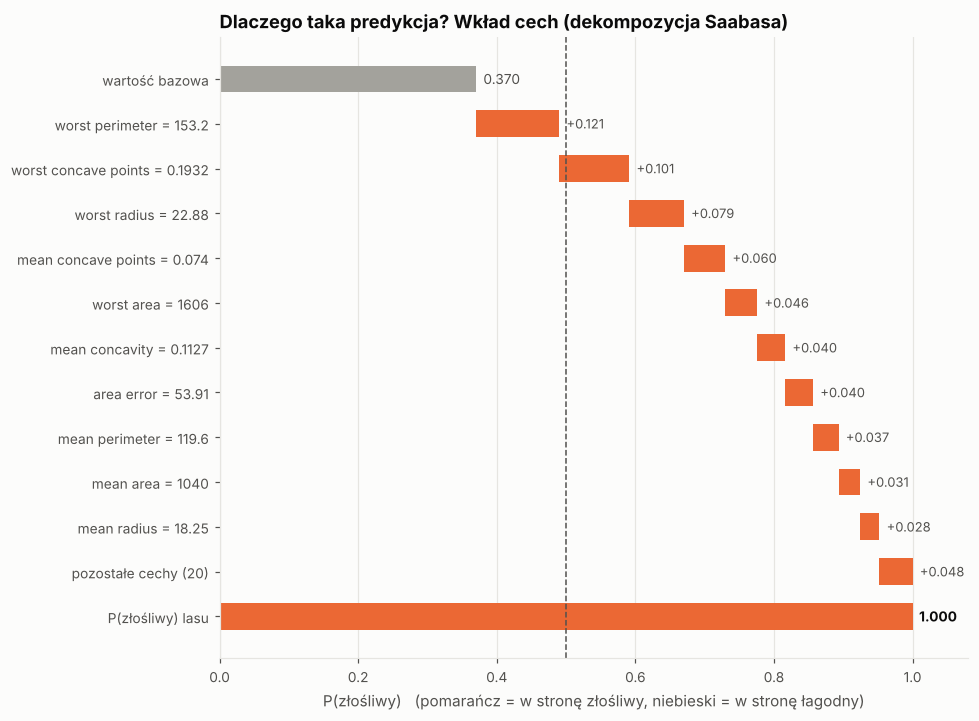

,drzewo,głos,P(złośliwy),głębokość,ścieżka
0,0,1,1.0,3,worst radius > 17 → mean smoothness > 0.0784 → mean concavity > 0.0726
1,1,1,1.0,4,worst radius > 17 → texture error > 0.511 → worst concave points > 0.0859 → worst texture > 20.3
2,2,1,1.0,5,worst concavity > 0.259 → mean fractal dimension ≤ 0.08 → mean area > 544 → smoothness error ≤ 0.00449 → mean concavity > 0.105
3,3,1,1.0,3,worst radius > 17 → worst perimeter > 110 → texture error > 0.474
4,4,1,1.0,4,worst concave points > 0.149 → concave points error ≤ 0.0415 → area error > 17.4 → radius error > 0.248


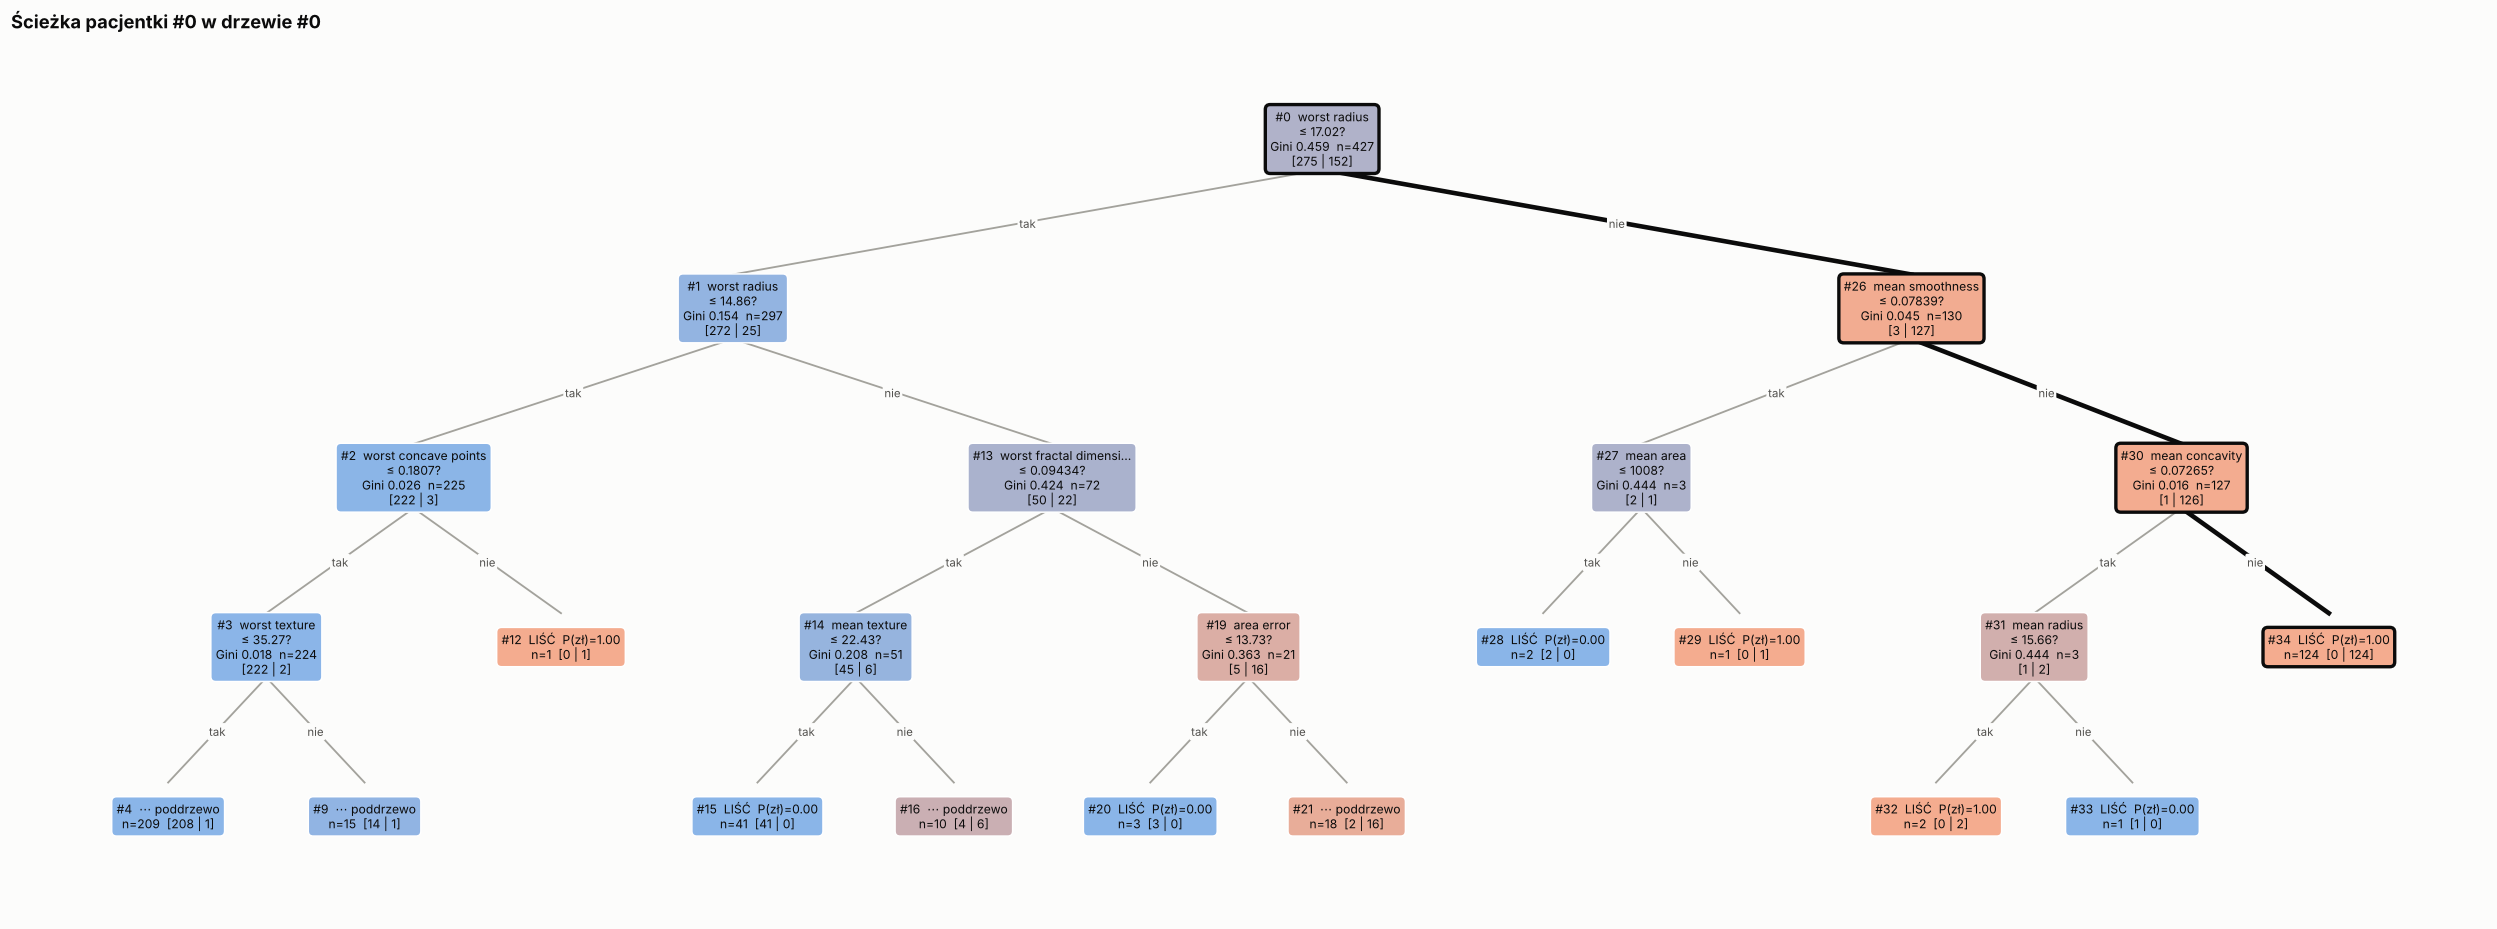

In [31]:
clear_case = int(np.argmax(np.where(y_test == 1, margins, -9)))   # złośliwy, największa zgodność drzew
explain_patient(clear_case)

### 10.2 Przypadek niepewny — tu wyjaśnienie jest najcenniejsze

Pacjentka testowa #31, prawdziwa diagnoza: ŁAGODNY

Las: ŁAGODNY, P(złośliwy) = 0.450. Głosy drzew: 45 za złośliwym, 55 za łagodnym (z 100). Punkt wyjścia (odsetek złośliwych w próbkach bootstrap) = 0.370. Najsilniejsze wkłady: worst concavity = 0.196 obniża P(złośliwy) o 0.084; mean concave points = 0.08534 podnosi P(złośliwy) o 0.083; worst concave points = 0.1423 podnosi P(złośliwy) o 0.078; worst perimeter = 105.9 obniża P(złośliwy) o 0.069. 

kontrola: bias + Σ wkładów = 0.450000;  predict_proba = 0.450000


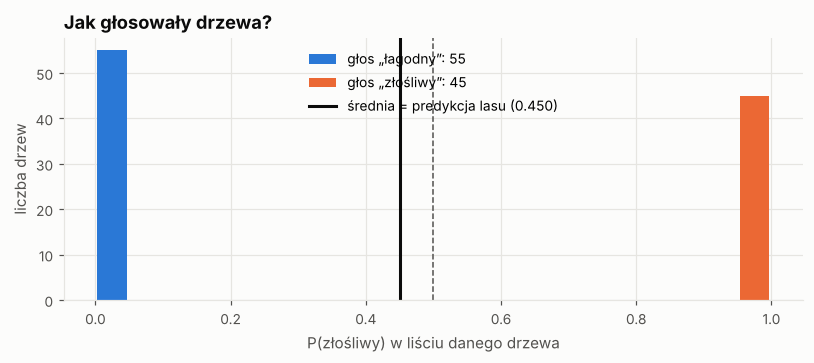

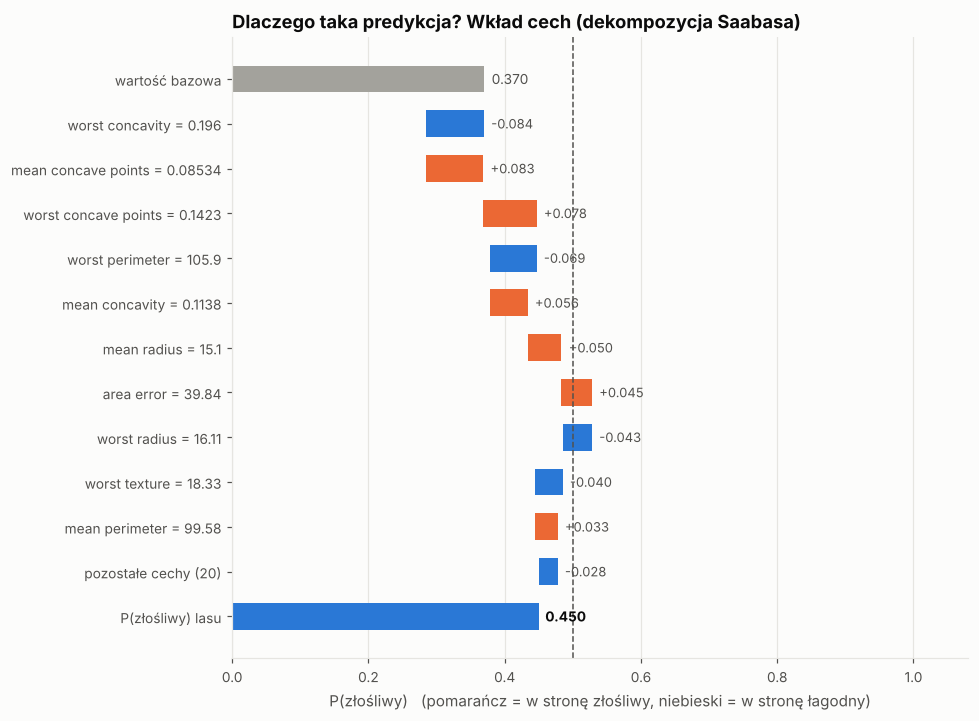

,drzewo,głos,P(złośliwy),głębokość,ścieżka
0,0,0,0.0,4,worst radius ≤ 17 → worst radius > 14.9 → worst fractal dimension ≤ 0.0943 → mean texture ≤ 22.4
1,1,1,1.0,6,worst radius ≤ 17 → mean smoothness ≤ 0.115 → worst perimeter > 101 → worst texture ≤ 29.6 → mean symmetry > 0.189 → perimeter error ≤ 3.68
2,2,0,0.0,3,worst concavity ≤ 0.259 → worst radius ≤ 16.8 → area error ≤ 91.6
3,3,1,1.0,6,worst radius ≤ 17 → worst fractal dimension ≤ 0.107 → mean perimeter > 93.2 → concave points error > 0.0127 → mean perimeter > 95.7 → me...
4,4,1,1.0,6,worst concave points ≤ 0.149 → worst area ≤ 975 → worst area ≤ 869 → worst fractal dimension > 0.0551 → worst concave points > 0.137 → w...


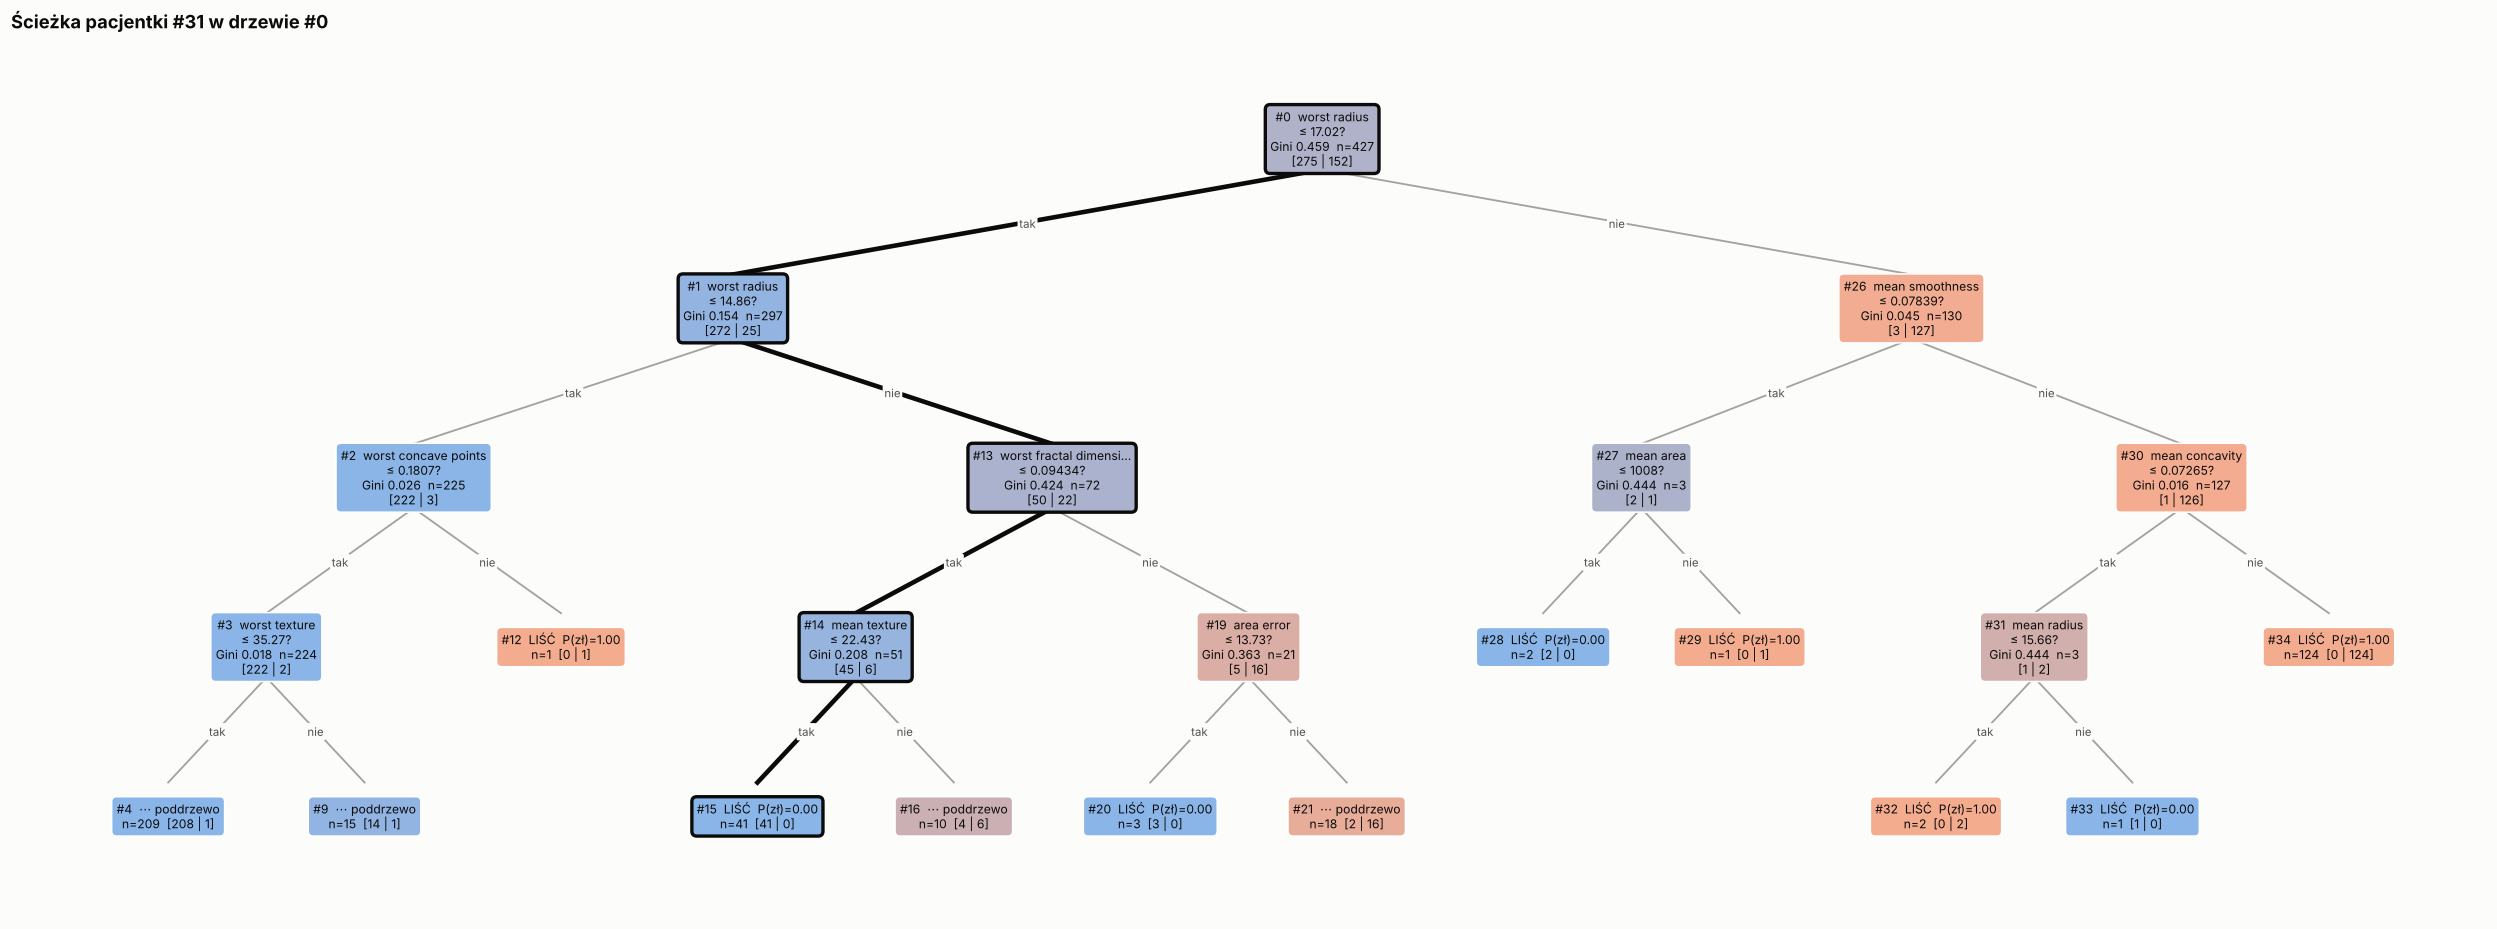

In [32]:
hard_case = int(np.argmin(np.abs(p_rf - 0.5)))                     # P(złośliwy) najbliżej 0,5
explain_patient(hard_case)

Zdarzenia `predict` także trafiły do dziennika:

In [33]:
for e in tracer.filter("predict"):
    print({k: e[k] for k in ("sample_id", "proba", "predicted", "hard_votes", "vote_margin")})

{'sample_id': 6, 'proba': [0.0, 1.0], 'predicted': 1, 'hard_votes': [0, 100], 'vote_margin': 1.0}
{'sample_id': 128, 'proba': [0.55, 0.45], 'predicted': 0, 'hard_votes': [55, 45], 'vote_margin': 0.1}


## 11. Dziennik jako ślad audytowy

Plik `rf_trace.jsonl` można wczytać niezależnie od modelu — np. żeby odpowiedzieć na pytanie *„w ilu drzewach i na jakiej głębokości użyto cechy X?”*.

In [34]:
log = pd.read_json("rf_trace.jsonl", lines=True)
print(log["event"].value_counts().to_string(), "\n")
splits = log[log.event == "node_split"]
(splits.groupby("name")
       .agg(liczba_podziałów=("node_id", "size"), drzew=("tree_id", "nunique"),
            średnia_głębokość=("depth", "mean"), suma_ważonego_zysku=("weighted_gain", "sum"))
       .sort_values("suma_ważonego_zysku", ascending=False).head(10).round(3))

event
leaf            1646
node_split      1546
bootstrap        100
tree_done        100
oob_progress     100
predict            2
forest_start       1
forest_done        1 



,liczba_podziałów,drzew,średnia_głębokość,suma_ważonego_zysku
name,,,,
worst perimeter,93,65,2.237,7.776
worst concave points,121,70,2.521,7.089
worst radius,85,58,2.553,4.942
mean concave points,83,52,2.542,4.633
worst area,87,60,2.713,2.892
area error,80,61,2.800,2.480
mean perimeter,41,30,2.561,2.417
mean concavity,54,44,2.537,2.349
mean area,45,38,2.822,1.984


## 12. Dlaczego (i kiedy) Random Forest?

**Za Random Forest na tych danych:**
* redukuje wariancję pojedynczego drzewa (sekcje 5 i 7) — stabilniejsze decyzje i wyższa czułość,
* daje **darmową walidację OOB** i ważność permutacyjną bez osobnego zbioru,
* nie wymaga skalowania cech i radzi sobie z nieliniowymi progami,
* każda decyzja jest **audytowalna**: dziennik + dekompozycja Saabasa.

**Uczciwie:** regresja logistyczna osiąga tu porównywalne (często lepsze) wyniki — ten zbiór jest prawie liniowo separowalny. Wybór modelu w medycynie powinien uwzględniać nie tylko AUC, ale też **kalibrację, interpretowalność i koszt błędów FN**. Las jest dobrym wyborem, gdy zależności są nieliniowe lub z interakcjami; prosty model liniowy — gdy wystarcza i jest łatwiejszy do wytłumaczenia klinicystom.

## Ćwiczenia
1. Ustaw `max_features=None` (czysty *bagging*). Jak zmienia się średnia niezgoda drzew, błąd OOB i rozkład cech w korzeniach?
2. Ustaw `max_features=1`. Drzewa są bardzo różne, ale słabe — co wygrywa?
3. Ogranicz `max_depth=3`. Porównaj wodospady Saabasa dla przypadku niepewnego.
4. Usuń z danych cechy `worst perimeter`, `worst radius`, `worst area` i porównaj ważność MDI z permutacyjną.
5. Dobierz próg decyzji tak, by czułość ≥ 0,98. Ile fałszywych alarmów to kosztuje?